<a href="https://colab.research.google.com/github/jjianhhao/SC3021/blob/main/SC3021_HDB_Resale_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# All relevant imports for the notebook
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from datetime import datetime
import sqlite3
from math import radians, sin, cos, sqrt, atan2
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)

# How do different Housing Development Board (HDB) flat to amenities affect Singapore HDB flat resale prices?
---

**Team Members:** Jian Hao, Ignatius, Ajitesh

**Lab Group:** SDAC, Group 9

---

# 1. Problem Formulation

## Background

Over 80% of Singapore residents live in HDB flats, making the resale market one of the most active property markets in the country. In recent years, we've seen resale prices climb steadily — even hitting record highs in 2023 — despite the government rolling out multiple rounds of cooling measures. At the same time, interest rates (SORA) jumped from near-zero during COVID to over 3.5%, directly increasing monthly mortgage payments for buyers.

As NTU students who will likely be entering the housing market in the next few years, we wanted to understand: **what actually drives HDB resale prices?**

## Problem Definition

Our project investigates the following question:

> **How do different Housing Development Board (HDB) flat attributes, proximity to amenities, government cooling measures, and macroeconomic conditions (interest rates) affect Singapore HDB resale flat prices?**

This is a **regression problem** at its core — we want to understand and eventually predict HDB resale prices based on a combination of:

- **Flat-level features**: floor area, storey range, flat type, remaining lease, flat age
- **Location-based features**: distance to nearest MRT station, distance to nearest shopping mall
- **Macroeconomic features**: prevailing SORA interest rates at the time of transaction
- **Policy-based features**: whether the transaction occurred before or after specific government cooling measures

## Why This Matters

This analysis is relevant to multiple stakeholders:

1. **Prospective homebuyers** — understanding what factors contribute most to price can help buyers prioritise what to look for (e.g., proximity to MRT vs. flat size vs. timing the market around policy changes)
2. **Policy makers** — evaluating whether cooling measures actually achieve their intended effect of moderating prices
3. **Urban planners** — quantifying the price premium associated with transport and retail accessibility

## Scope

- **Time period**: January 2017 to December 2024
- **Geography**: All 26 HDB towns across Singapore
- **Transaction type**: Resale transactions only (excludes BTO and rental)
- **Target variable**: `resale_price` (continuous, in SGD)

# 2. Requirement Analysis

## What Do We Need to Answer Our Question?

To investigate what drives HDB resale prices, we need to bring together multiple types of data and connect them meaningfully. Here's what we identified:

### Data Requirements

| Requirement | What We Need | Why |
|------------|-------------|-----|
| Transaction data | HDB resale records with price, flat type, floor area, lease info | This is our **target variable** and contains core flat-level features |
| Transport accessibility | MRT/LRT station locations with coordinates | To compute **distance to nearest MRT** for each flat — tests whether transport access affects price |
| Retail accessibility | Shopping mall locations with coordinates | To compute **distance to nearest mall** — tests whether retail proximity affects price |
| Interest rates | Historical SORA rates (daily/monthly) | To capture the **macroeconomic environment** at the time of each transaction |
| Policy timeline | Dates and details of government cooling measures | To create **before/after policy indicators** for measuring policy impact on prices |
| Geocoding service | API to convert HDB block addresses to lat/long coordinates | Required to calculate distances — HDB data only has street addresses, not coordinates |

### Analytical Requirements

To properly test our hypotheses, we need the following types of analysis:

**Descriptive Analysis** — Understand the basic distributions: how are prices spread across towns, flat types, and time periods? Are there obvious trends or outliers?

**Correlation & Diagnostic Analysis** — Measure relationships between price and our features (distance to MRT, SORA rates, flat attributes). We'll use correlation matrices and scatter plots to identify which factors have the strongest associations.

**Hypothesis Testing** — Statistical tests to evaluate specific claims:
- t-tests or Mann-Whitney U tests to compare prices before/after cooling measures
- Correlation significance tests for SORA vs. price relationships
- Comparison of prices within 500m of MRT vs. further away

**Predictive Modelling** — Build regression models (starting with Linear Regression, then potentially Random Forest) to predict resale prices and measure feature importance. Target: R² > 0.7.

### Technical Requirements

- **Geocoding**: We need to convert ~10,000 unique HDB addresses to coordinates using the OneMap API (rate limit: 250 requests/min, so we need batching and caching)
- **Distance computation**: Haversine formula to calculate great-circle distances between HDB flats and amenities
- **Data integration**: Merging 5 datasets on common keys (month/year for temporal data, coordinates for spatial data)
- **Storage**: SQLite database for the integrated dataset to enable SQL-based queries

### Key Assumptions

1. Resale price is primarily influenced by flat attributes, location, macroeconomic conditions, and policy interventions
2. Straight-line (Haversine) distance is a reasonable proxy for actual walking distance to amenities
3. Monthly average SORA is representative of the interest rate environment at the time of transaction
4. The effects of cooling measures can be observed within 3-6 months of implementation

## Hypothesis/analysis goal (Ask)

## Problem Statement

The Singapore HDB resale market is influenced by multiple complex factors including flat attributes (square feet, floor etc.), government cooling measures, macroeconomic conditions (interest rates), and locational attributes (proximity to amenities). Understanding how these factors interact to influence resale prices is crucial for:

1. **Home buyers** seeking to make informed purchasing decisions
2. **Policy makers** evaluating the effectiveness of housing policies
3. **Urban planners** understanding the value of amenity accessibility

## Research Questions

We aim to answer the following questions:

1. **Flat Attributes** Do flat attributes lead to changes in flat prices?
2. **Policy Impact**: Do HDB cooling measures lead to measurable changes in resale prices following their implementation?
3. **Interest Rate Effect**: How do SORA (Singapore Overnight Rate Average) fluctuations correlate with resale price trends?
4. **Amenity Proximity**: Does proximity to MRT stations and shopping malls significantly correlate with higher resale prices?
5. **Predictive Modeling**: Can we build a model to predict HDB resale prices based on these factors? (Linear Regression / Random Forest)

## Hypotheses

- **H1**: Implementation of cooling measures (e.g., increased ABSD, tightened LTV) leads to a decrease in median resale prices within 3-6 months.
- **H2**: Higher SORA rates negatively correlate with resale prices due to increased mortgage costs reducing buyer affordability.
- **H3**: HDB flats within 500m of MRT stations command a price premium of at least 5% compared to those further away.
- **H4**: A combination of flat characteristics, location features, and macroeconomic indicators can predict resale prices with R² > 0.7.

## Analysis Types Required

| Analysis Type | Application |
|--------------|-------------|
| **Descriptive** | Price distributions by town, flat type, time period |
| **Diagnostic** | Correlation analysis between prices and influencing factors |
| **Predictive** | Regression model for price prediction |
| **Prescriptive** | Recommendations for buyers based on findings |

## Quality Metrics

- **Prediction Model**: R² score > 0.7, RMSE < $50,000

# Data Source Identification and Exploration (Prepare)


## Overview of Data Sources

We utilise **5 data sources** to analyse HDB resale prices:

| ID | Dataset | Source | Format | Records | Purpose |
|----|---------|--------|--------|---------|--------|
| DS1 | HDB Resale Flat Prices | Kaggle / data.gov.sg | CSV | ~181,000 | Main dataset - target variable |
| DS2 | MRT/LRT Station Coordinates | Kaggle | CSV | 157 | Transport accessibility analysis |
| DS3 | Singapore Malls POI | Kaggle | CSV | 249 | Retail amenity proximity |
| DS4 | SORA Interest Rates | MAS | CSV | ~2,000 | Macroeconomic factor |
| DS5 | HDB Cooling Measures | Manual compilation | CSV | 9 | Policy impact analysis |
| API | OneMap Geocoding | OneMap.sg | REST API | - | Address to coordinates conversion |

## DS1: HDB Resale Flat Prices (2017-2024)

**Source**: [Kaggle - Singapore Resale Flat Prices](https://www.kaggle.com/datasets/darrylljk/singapore-hdb-resale-flat-prices-2017-2024) / [data.gov.sg](https://data.gov.sg/datasets/d_8b84c4ee58e3cfc0ece0d773c8ca6abc/view)

**Description**: Transaction records of HDB resale flats from January 2017 onwards, including flat characteristics and transaction prices, offering relevant information for our analysis. It includes the street name and block number, which are at an appropriate level of granularity to combine with the other datasets for appropriate geospatial analysis. The following code imports the data into a DataFrame and displays the head, giving an illustration of the data.

In [2]:
# Load DS1: HDB Resale Flat Prices
df1 = pd.read_csv('https://raw.githubusercontent.com/jjianhhao/SC3021/refs/heads/main/data/sg-resale-flat-prices-2017-onwards.csv')

print("DS1: HDB RESALE FLAT PRICES (2017-2024)")
df1.head()

DS1: HDB RESALE FLAT PRICES (2017-2024)


,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price
0,2017-01,ANG MO KIO,2 ROOM,406,ANG MO KIO AVE 10,10 TO 12,44.0,Improved,1979,61 years 04 months,232000.0
1,2017-01,ANG MO KIO,3 ROOM,108,ANG MO KIO AVE 4,01 TO 03,67.0,New Generation,1978,60 years 07 months,250000.0
2,2017-01,ANG MO KIO,3 ROOM,602,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,262000.0
3,2017-01,ANG MO KIO,3 ROOM,465,ANG MO KIO AVE 10,04 TO 06,68.0,New Generation,1980,62 years 01 month,265000.0
4,2017-01,ANG MO KIO,3 ROOM,601,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,265000.0


In [3]:
# DS1: Data types and missing values
print("DATA TYPES AND MISSING VALUES")
df1.info()

DATA TYPES AND MISSING VALUES
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 181262 entries, 0 to 181261
Data columns (total 11 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   month                181262 non-null  object 
 1   town                 181262 non-null  object 
 2   flat_type            181262 non-null  object 
 3   block                181262 non-null  object 
 4   street_name          181262 non-null  object 
 5   storey_range         181262 non-null  object 
 6   floor_area_sqm       181262 non-null  float64
 7   flat_model           181262 non-null  object 
 8   lease_commence_date  181262 non-null  int64  
 9   remaining_lease      181262 non-null  object 
 10  resale_price         181262 non-null  float64
dtypes: float64(2), int64(1), object(8)
memory usage: 15.2+ MB


From an initial inspection of the dataset, several variables require transformation before meaningful analysis can be performed. The remaining_lease field is stored as a textual description rather than a numeric value, which limits its direct use in statistical analysis and modeling. As lease duration is an important quantitative factor, this variable needs to be parsed and converted into numeric years.

In addition, the month variable is currently represented as a YYYY-MM format, which prevents it from being used for time-based operations such as sorting, filtering, or merging with external temporal datasets. Converting this field into a proper datetime format ensures consistency and enables time-series analysis.

The `block` column itself also cannot function alone as there many blocks with the same number but different locations. Therefore, to make the column meaningful, we have decided to combine the `block` and `address` column to make the data more unique.

Finally, while location-related attributes are present, they are distributed across multiple columns (street_name, block, town). To support geocoding and spatial analysis, these components need to be combined into a single address field that can be interpreted by geocoding services.

In [4]:
# DS1: Statistical summary
print("STATISTICAL SUMMARY (Numerical Columns)")
df1.describe()

STATISTICAL SUMMARY (Numerical Columns)


,floor_area_sqm,lease_commence_date,resale_price
count,181262.000000,181262.000000,1.812620e+05
mean,97.152903,1996.013842,4.978643e+05
std,24.025926,14.041087,1.726320e+05
min,31.000000,1966.000000,1.400000e+05
25%,82.000000,1985.000000,3.700000e+05
50%,93.000000,1996.000000,4.680000e+05
75%,112.000000,2010.000000,5.920000e+05
max,249.000000,2020.000000,1.588000e+06


From the looks of the statistical summary of the numerical columns in our dataset, it is quite clear that there are some anomalies (or rather outliers). The overall dataset tend to be right skewed as the max values far exceeds the mean and the standard deviation. This is however not surprising as there are some HDB flats which are of a higher tier which can inflate the prices. Moving forward, we decided to continue the dataset exploration to see if we should keep these values.

In [5]:
# DS1: Categorical column distributions
print("CATEGORICAL DISTRIBUTIONS")

categorical_cols = ['town', 'flat_type', 'flat_model', 'storey_range', 'street_name']

for col in categorical_cols:
    print(f"\n{col.upper()} ({df1[col].nunique()} unique values):")
    print(df1[col].value_counts().head(5))
    print(df1[col].value_counts().tail(10))

CATEGORICAL DISTRIBUTIONS

TOWN (26 unique values):
town
SENGKANG     14993
PUNGGOL      13448
WOODLANDS    12847
YISHUN       12429
TAMPINES     12139
Name: count, dtype: int64
town
QUEENSTOWN       5002
SEMBAWANG        4957
GEYLANG          4428
CLEMENTI         4070
JURONG EAST      3725
SERANGOON        3311
BISHAN           3284
CENTRAL AREA     1463
MARINE PARADE    1118
BUKIT TIMAH       456
Name: count, dtype: int64

FLAT_TYPE (7 unique values):
flat_type
4 ROOM       76457
5 ROOM       45059
3 ROOM       42908
EXECUTIVE    13474
2 ROOM        3218
Name: count, dtype: int64
flat_type
4 ROOM              76457
5 ROOM              45059
3 ROOM              42908
EXECUTIVE           13474
2 ROOM               3218
MULTI-GENERATION       78
1 ROOM                 68
Name: count, dtype: int64

FLAT_MODEL (21 unique values):
flat_model
Model A              63164
Improved             44622
New Generation       22514
Premium Apartment    20466
Simplified            6968
Name: count, d

From the number of unique values of the dataset, it is clear that there are some categories that appear rarely especially in the `flat_model` and`storey_range` column with a huge variance in the count of values. Since the categories with such a low count cannot provide any meaningful insights, we have to clear them for a more meaningful analysis. This is natural as higher end HDB flats tend to be on higher floors and are definitely lower in quantity which might also explain the right skewed distribution of the prices.

In [6]:
# DS1: Finding if there are duplicated values

df1.duplicated().sum()

np.int64(288)

There are 288 duplicated values which require cleaning.

month                  0
town                   0
flat_type              0
block                  0
street_name            0
storey_range           0
floor_area_sqm         0
flat_model             0
lease_commence_date    0
remaining_lease        0
resale_price           0
dtype: int64


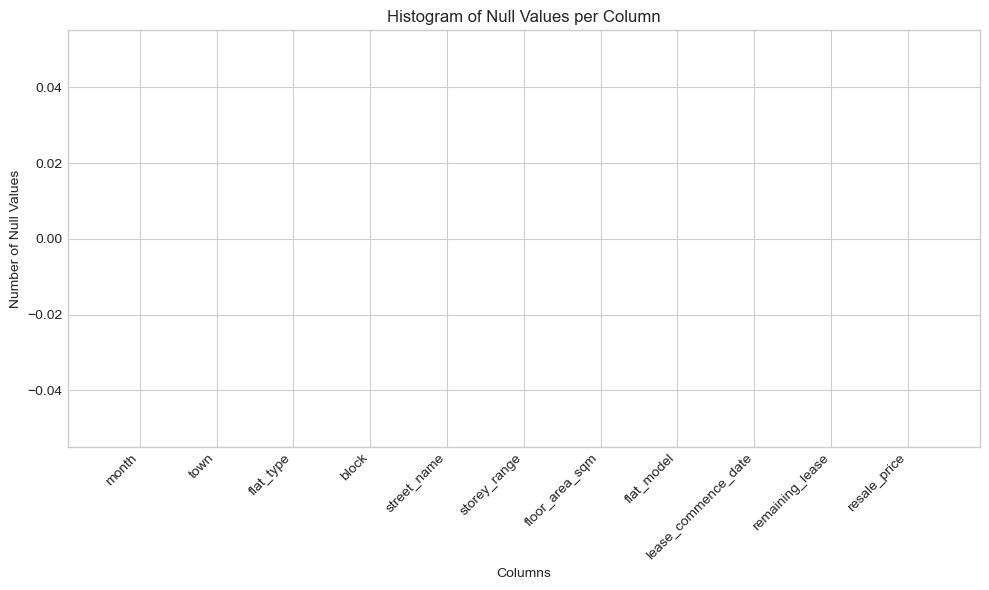

In [7]:
null_counts = df1.isnull().sum()
print(null_counts)

plt.figure(figsize=(10, 6))
plt.bar(null_counts.index, null_counts.values)
plt.xlabel("Columns")
plt.ylabel("Number of Null Values")
plt.title("Histogram of Null Values per Column")
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for readability
plt.tight_layout()
plt.show()


### DS1 Assessment:

*   The dataset satisfies our requirement for the task at hand as it is quite comprehensive in the coverage of many flat characteristics and resale price. It works well with the other datasets to be used with minimal cleaning needed.
*   The interpretability of the dataset is high with attributes being easy to understand.
* This dataset is obtained from Kaggle which is well used in the data science community. The reputation of the dataset is good as this Kaggle dataset is taken from data.gov.sg, an official government dataset website.

This dataset ideally fits our data requirements and hence we will be using it.

###Conclusion:

**Data Quality**:
- No missing values across all 181,262 records
- 288 duplicated rows

**Key Observations**:
- Price range: $140,000 - $1,588,000 (median: $468,000) (Right Skewed)
- Floor area: 31-249 sqm (median: 93 sqm)
- 26 unique towns, 7 flat types, 21 flat models

**Required Transformations**:
1. Parse `remaining_lease` to numeric years
2. Convert `month` to datetime
3. Create `address` column for geocoding
4. Combine `block` and `address` columns

**Required Cleaning**
- Remove duplicated rows
- Remove outliers

DS1 provides much information of the flat characteristics and resale price

## DS2: MRT/LRT Station Coordinates

**Source**: [Kaggle - Singapore MRT & LRT Stations with Coordinates
](https://www.kaggle.com/datasets/shengjunlim/singapore-mrt-lrt-stations-with-coordinates?resource=download)

**Description**: Geographic coordinates (latitude, longitude) of all MRT and LRT stations in Singapore. It has four main columns `OBJECTID`, `station_name`, `station_no`, `geometry`, `lat`, `lng`.

**Main Purpose**: Calculate distance from each HDB flat to nearest train station as distance to nearest train station is a factor in HDB flat prices.

In [8]:
# Load DS2: MRT/LRT Station Coordinates
df2 = pd.read_csv('https://raw.githubusercontent.com/jjianhhao/SC3021/refs/heads/main/data/MRT Stations.csv', index_col = 0)

print("DS2: MRT/LRT STATION COORDINATES")
df2.head(10)

DS2: MRT/LRT STATION COORDINATES


,OBJECTID,station_name,station_no,geometry,lat,lng
0,1,EUNOS MRT STATION,EW7,POINT (103.9032524667383 1.319778951553637),1.319779,103.903252
1,2,CHINESE GARDEN MRT STATION,EW25,POINT (103.7325967380734 1.342352820874744),1.342353,103.732597
2,3,KHATIB MRT STATION,NS14,POINT (103.8329799077383 1.417383370153547),1.417383,103.832980
3,4,KRANJI MRT STATION,NS7,POINT (103.7621654109002 1.425177698770448),1.425178,103.762165
4,5,REDHILL MRT STATION,EW18,POINT (103.816816670149 1.289562726402453),1.289563,103.816817
5,6,YEW TEE MRT STATION,NS5,POINT (103.7474051141379 1.397535017793412),1.397535,103.747405
6,7,PIONEER MRT STATION,EW28,POINT (103.6973215129361 1.337586882204749),1.337587,103.697322
7,8,COMMONWEALTH MRT STATION,EW20,POINT (103.798304515629 1.30243873532717),1.302439,103.798305
8,9,PAYA LEBAR MRT STATION,EW8/CC9,POINT (103.8930603552516 1.318112082295278),1.318112,103.893060
9,10,SIMEI MRT STATION,EW3,POINT (103.9533716941757 1.343202894930727),1.343203,103.953372


From the head of the dataset, we can see that some columns are not relevant to us and can be dropped. For example, we only need the `station_name` along with its latitude and longitude for subsequent geospatial analysis

In [9]:
#DS2 Dataset information

df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 171 entries, 0 to 170
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   OBJECTID      171 non-null    int64  
 1   station_name  171 non-null    object 
 2   station_no    171 non-null    object 
 3   geometry      171 non-null    object 
 4   lat           171 non-null    float64
 5   lng           171 non-null    float64
dtypes: float64(2), int64(1), object(3)
memory usage: 9.4+ KB


From the information of this dataset, we can see that there are 171 entries with all of them not being null values. The data types of the dataset is also consistent with `OBJECTID` being `int`, `lat` and `lng` being `float` and the rest being `string`. Therefore, no transformation is needed for this dataset.

In [10]:
# DS2: Data quality check
print("DS2 DATA QUALITY CHECK")
print(f"\nMissing values: {df2.isnull().sum().sum()}")
print(f"Duplicate stations: {df2.duplicated(subset=['station_name']).sum()}")
print(f"\nCoordinate ranges:")
print(f"  lat:  {df2['lat'].min():.4f} to {df2['lat'].max():.4f}")
print(f"  lng: {df2['lng'].min():.4f} to {df2['lng'].max():.4f}")

# Verify coordinates are within Singapore bounds
sg_bounds = {'lat_min': 1.15, 'lat_max': 1.47, 'lng_min': 103.6, 'lng_max': 104.1}
valid_coords = (
    (df2['lat'] >= sg_bounds['lat_min']) & (df2['lat'] <= sg_bounds['lat_max']) &
    (df2['lng'] >= sg_bounds['lng_min']) & (df2['lng'] <= sg_bounds['lng_max'])
).all()
print(f'Valid coordinates: ',{valid_coords})

DS2 DATA QUALITY CHECK

Missing values: 0
Duplicate stations: 0

Coordinate ranges:
  lat:  1.2655 to 1.4491
  lng: 103.6369 to 103.9884
Valid coordinates:  {np.True_}


From the data quality checks, we can see that there are no missing or duplicate values. Each coordinate from this dataset also falls within Singapore. Hence, there are minimal data errors.

### DS2 Assessment

*   This dataset satisfies our requirement for the its purpose which is to provide coordinates of amenities for geospatial analysis.
*   The interpretability of the dataset is high, given that it limits to few essential attributes with clear semantics. This makes misinterpretation and misuse highly during analysis highly unlikely.
* However, the reputation of the dataset remains unclear. The source of this dataset is unclear and there is no updates on new stations. According to [SGTrain.com](https://www.sgtrains.com/network-figures.html), there are currently 185 train stations - meaning that there are 14 unreported stations in this dataset. This is bound to happen as new MRT and LRT stations are constantly being build, hence without frequent updates, not all stations are reported.

Despite the moderate reputation, the dataset ideally fits our data requirements so we eventually opted to use it. We are however aware that potential errors in the data can affect the accuracy of the trained model.

## Conclusion

**Data Quality**:
- 171 stations with complete coordinate data
- All coordinates within valid Singapore bounds
- Mix of MRT and LRT stations

**Limitations**:
- May not include newest stations (e.g., some Thomson-East Coast Line stations)
- No opening date information

**Usage**: Will calculate Haversine distance from each HDB flat to all stations, then take minimum.

## DS3: Singapore Malls POI

**Source**: [Kaggle - Singapore Malls POI](https://www.kaggle.com/datasets/sunnysharma432/singapore-malls-pois)

**Description**: Point of Interest (POI) data for shopping malls in Singapore.

**Purpose**: Calculate distance from each HDB flat to nearest shopping mall.

In [11]:
# Load DS3: Singapore Malls POI
df3 = pd.read_csv('https://raw.githubusercontent.com/jjianhhao/SC3021/refs/heads/main/data/singapore_malls_pois.csv')

print("DS3: SINGAPORE MALLS POI")
df3.head()

DS3: SINGAPORE MALLS POI


,name,category,lat,lon,brand,address,website,phone
0,The Star Vista,mall,1.308002,103.788382,NaN,Vista Exchange Green,NaN,NaN
1,Bencoolen Underground Mall,mall,1.298181,103.849647,NaN,NaN,NaN,NaN
2,Bencoolen Underground Mall,mall,1.299224,103.850755,NaN,NaN,NaN,NaN
3,Katong V,mall,1.303133,103.903231,NaN,Marine Parade Road,NaN,NaN
4,The Poiz Centre,mall,1.331436,103.868571,NaN,Upper Serangoon Road,https://thepoizcentre.com.sg/,NaN


The dataset consists of 8 columns: `name`, `category`, `lat`, `lon`, `brand`, `address`, `website` and `phone`. Since the longitude column for our other datasets has always been labelled as `lng`, we will change the column name to `lng` for better comparison and joining.

We can also see that there are many null values and hence we have to explore the specific number of null values for each column.

In [12]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 249 entries, 0 to 248
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   name      235 non-null    object 
 1   category  249 non-null    object 
 2   lat       249 non-null    float64
 3   lon       249 non-null    float64
 4   brand     0 non-null      float64
 5   address   205 non-null    object 
 6   website   72 non-null     object 
 7   phone     41 non-null     object 
dtypes: float64(3), object(5)
memory usage: 15.7+ KB


From the information from the dataset, there are 249 entries. Since we are only concerned with the latitude and longitude columns, we can see that both columns have exactly 249 entries which means that the data that we need is complete. Other attributes like brand, address, website and phone are not needed and we can drop those columns.



In [13]:
# DS3: Data quality check
print("DS3 DATA QUALITY CHECK")
print(df3.isnull().sum())
print(f"\nDuplicate mall names: {df3.duplicated(subset=['name']).sum()}")
print(f"Unique malls: {df3['name'].nunique()}")

# Check coordinate validity
valid_coords = (
    (df3['lat'] >= 1.15) & (df3['lat'] <= 1.47) &
    (df3['lon'] >= 103.6) & (df3['lon'] <= 104.1)
).all()
print(f"\nAll coordinates within Singapore bounds: {valid_coords}")

DS3 DATA QUALITY CHECK
name         14
category      0
lat           0
lon           0
brand       249
address      44
website     177
phone       208
dtype: int64

Duplicate mall names: 29
Unique malls: 219

All coordinates within Singapore bounds: True


We test the integrity of the data here using the coordinates columns. After checking, the data is mostly accurate with data points all being within Singapore.

### DS3 Assessment

Like the previous dataset, the dataset has a reliability issue as no source of data is being mentioned. Hence this may affect the reliability of the results.

The reason for the sheer amount of null values can be attributed to the fact that not all malls have a website and a phone number. The dataset lacks much information in other aspects but since the columns that we are using is present and truthful, we choose to continue using this dataset.

**Data Quality**:
- 249 mall entries, but 29 duplicates
- Some missing addresses (120 nulls) - acceptable since we have coordinates
- `brand`, `website`, `phone` columns not needed - will drop

**Required Transformations**:
1. Remove duplicate entries
2. Drop unnecessary columns
3. Rename `lon` to `lng` for consistency with DS2

## DS4: SORA Interest Rates (2017-2026)

**Source**: [Monetary Authority of Singapore (MAS)](https://eservices.mas.gov.sg/statistics/msb/ExchangeRates.aspx)

**Description**: Singapore Overnight Rate Average (SORA) - the benchmark interest rate used for HDB loans since 2020.

**Purpose**: Analyze correlation between interest rates and resale prices (macroeconomic factor).

In [14]:
# Load DS4: SORA Interest Rates
df4 = pd.read_csv('https://raw.githubusercontent.com/jjianhhao/SC3021/refs/heads/main/data/Domestic Interest Rates.csv')

print("DS4: SORA INTEREST RATES (2017-2026)")
print(f"\nDate Range: {df4['Date'].iloc[0]} to {df4['Date'].iloc[-1]}")
df4.head()

DS4: SORA INTEREST RATES (2017-2026)

Date Range: 3/1/2017 to 23/1/2026


,Date,SORA,Compound SORA - 3 month,Compound SORA - 6 month
0,3/1/2017,0.2354,0.1478,0.1400
1,4/1/2017,0.1257,0.1488,0.1399
2,5/1/2017,0.1040,0.1494,0.1399
3,6/1/2017,0.1122,0.1498,0.1403
4,9/1/2017,0.0523,0.1490,0.1402


This dataset consists of 4 columns: `Date`, `SORA`, `Compound SORA - 3 month` and `Compount SORA - 6 month`.

From the head of the dataset, all values seem valid and no anomalies can be seen. However, more data exploration must be done to confirm that this dataset can be used effectively.

In [15]:
df4.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2275 entries, 0 to 2274
Data columns (total 4 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Date                     2275 non-null   object 
 1   SORA                     2275 non-null   float64
 2   Compound SORA - 3 month  2275 non-null   float64
 3   Compound SORA - 6 month  2275 non-null   float64
dtypes: float64(3), object(1)
memory usage: 71.2+ KB


From the information of the dataset, we can see that there are 2275 entries with all columns having no null values.

The data type of the columns are also consistent with `Date` being in a `String` format and the other `SORA` columns having a `float` data type.

In [16]:
df4.duplicated().sum()

np.int64(0)

There are no duplicates in this dataset. Hence, this dataset is relatively clean and can be used for training.

In [17]:
# DS4: Statistical summary
print("DS4 STATISTICAL SUMMARY")
df4.describe()

DS4 STATISTICAL SUMMARY


,SORA,Compound SORA - 3 month,Compound SORA - 6 month
count,2275.000000,2275.000000,2275.000000
mean,1.537003,1.548021,1.537608
std,1.288747,1.275300,1.277059
min,0.009300,0.069600,0.094500
25%,0.310600,0.338200,0.345100
50%,1.243100,1.229500,1.251400
75%,2.600250,2.748400,2.667350
max,4.391600,3.761100,3.748000


From the statistical summary, values fall in a reasonable range showing that there are no extreme values and outliers.

### DS4 Assessment

As this dataset is from the MAS, a government website, this dataset is reliable.

As the dataset provides many instances and different types of interest rates, there is a large breadth of data that we can use for analysis. Therefore with the clean nature of this dataset and the vast amount of data that we can use, we choose to proceed with this dataset.

**Data Quality**: Good
- Daily SORA rates from 2017 onwards
- Includes 3-month and 6-month compound rates

**Key Observations**:
- SORA ranged from near-zero (2020-2021) to over 3.5% (2023-2024)
- Clear correlation expected with housing affordability

**Required Transformations**:
1. Parse `Date` to datetime
2. Aggregate to monthly average for merging with DS1
3. Create `year_month` column for joining

## DS5: HDB Cooling Measures (2017-2024)

**Source**: Manual compilation from HDB, MAS, and government announcements

**Description**: Timeline of government housing policies and cooling measures that may impact resale prices.

**Purpose**: Analyze price trends before/after policy implementations.

In [18]:
# DS5: HDB Cooling Measures (manually compiled)
cooling_measures = {
    'date': [
        '2017-03-10', '2018-07-06', '2019-09-20', '2021-09-15',
        '2021-12-16', '2022-09-30', '2023-04-26', '2024-02-15', '2024-08-20'
    ],
    'measure_name': [
        'Enhanced CPF Housing Grant',
        'Tightened Loan-to-Value (LTV) Limits',
        'CPF Housing Grant Changes',
        'Wait-Out Period for Private Property Owners',
        'LTV Limits Tightened Further',
        'ABSD Rate Increase',
        'Prime Location Public Housing (PLH) Model',
        'Enhanced CPF Housing Grant Increased',
        'Fresh Start Housing Scheme'
    ],
    'category': [
        'Grant', 'Financial', 'Grant', 'Eligibility',
        'Financial', 'Financial', 'Eligibility', 'Grant', 'Eligibility'
    ],
    'severity': [
        'Medium', 'Medium', 'Low', 'High',
        'High', 'High', 'High', 'Low', 'Low'
    ],
    'expected_impact': [
        'Positive', 'Cooling', 'Mixed', 'Cooling',
        'Cooling', 'Cooling', 'Cooling', 'Positive', 'Neutral'
    ],
    'description': [
        'EHG introduced, up to $80,000 for families',
        'LTV reduced from 90% to 85% for loans >25 years',
        'Adjustments to income ceilings and grant amounts',
        '15-month wait-out period for private property sellers',
        'HDB loan LTV capped at 85%, bank loan at 75%',
        'ABSD for 2nd property: 17%, PRs 1st: 5%',
        '10-year MOP, 6% subsidy clawback for prime areas',
        'Maximum EHG increased to $120,000',
        'Shorter wait time for divorced/separated singles'
    ]
}

df5 = pd.DataFrame(cooling_measures)
df5['date'] = pd.to_datetime(df5['date'])

print("DS5: HDB COOLING MEASURES (2017-2024)")
print(f"\nTotal measures: {len(df5)}")
print(f"\nBy Category: {df5['category'].value_counts().to_dict()}")
print(f"By Severity: {df5['severity'].value_counts().to_dict()}")
print(f"By Expected Impact: {df5['expected_impact'].value_counts().to_dict()}")

df5

DS5: HDB COOLING MEASURES (2017-2024)

Total measures: 9

By Category: {'Grant': 3, 'Financial': 3, 'Eligibility': 3}
By Severity: {'High': 4, 'Low': 3, 'Medium': 2}
By Expected Impact: {'Cooling': 5, 'Positive': 2, 'Mixed': 1, 'Neutral': 1}


,date,measure_name,category,severity,expected_impact,description
0,2017-03-10,Enhanced CPF Housing Grant,Grant,Medium,Positive,"EHG introduced, up to $80,000 for families"
1,2018-07-06,Tightened Loan-to-Value (LTV) Limits,Financial,Medium,Cooling,LTV reduced from 90% to 85% for loans >25 years
2,2019-09-20,CPF Housing Grant Changes,Grant,Low,Mixed,Adjustments to income ceilings and grant amounts
3,2021-09-15,Wait-Out Period for Private Property Owners,Eligibility,High,Cooling,15-month wait-out period for private property ...
4,2021-12-16,LTV Limits Tightened Further,Financial,High,Cooling,"HDB loan LTV capped at 85%, bank loan at 75%"
5,2022-09-30,ABSD Rate Increase,Financial,High,Cooling,"ABSD for 2nd property: 17%, PRs 1st: 5%"
6,2023-04-26,Prime Location Public Housing (PLH) Model,Eligibility,High,Cooling,"10-year MOP, 6% subsidy clawback for prime areas"
7,2024-02-15,Enhanced CPF Housing Grant Increased,Grant,Low,Positive,"Maximum EHG increased to $120,000"
8,2024-08-20,Fresh Start Housing Scheme,Eligibility,Low,Neutral,Shorter wait time for divorced/separated singles


### DS5 Assessment

**Data Quality**: Complete (manually curated)
- 9 major policy changes documented
- Categorized by type, severity, and expected impact

**Key Observations**:
- 4 "High" severity cooling measures (2021-2023)
- Mix of cooling (restrictive) and supportive (grant) measures

**Usage**: Create indicator variables for before/after analysis of each policy.

## API: OneMap Geocoding Service

**Source**: [OneMap API](https://www.onemap.gov.sg/apidocs/)

**Description**: Singapore government's official geocoding API for converting addresses to coordinates.

**Purpose**: Convert HDB addresses (block + street) to latitude/longitude for distance calculations.

In [19]:
# OneMap API - Geocoding Function
def geocode_address(search_val):
    url = f"https://www.onemap.gov.sg/api/common/elastic/search"
    params = {
        'searchVal': search_val,
        'returnGeom': 'Y',
        'getAddrDetails': 'Y'
    }

    try:
        response = requests.get(url, params=params, timeout=10)
        data = response.json()

        if data.get('found', 0) > 0:
            result = data['results'][0]
            return float(result['LATITUDE']), float(result['LONGITUDE'])
    except Exception as e:
        print(f"Error geocoding '{search_val}': {e}")

    return None, None

# Test the API with a sample address
test_address = "406 ANG MO KIO AVE 10"
lat, lng = geocode_address(test_address)

print("ONEMAP API TEST")
print(f"Test Address: {test_address}")
print(f"Result: Latitude={lat}, Longitude={lng}")

ONEMAP API TEST
Test Address: 406 ANG MO KIO AVE 10
Result: Latitude=1.36200453938712, Longitude=103.853879910407


### OneMapAPI Assessment

The OneMapAPI is essential to our project as we heavily work with coordinates and finding the closest distance between HDB flats and amenities (Shopping Malls and Transportation).

As this API is rate limited to 250 requests/minute, we can cache the results of each call to avoid any additional API calls. Together with the haversine function that we have to implement later, we can calculate the distance between the HDB flats to the nearest amentities.

**Availability**: Working
- Free tier: 250 requests/minute
- Returns accurate WGS84 coordinates

**Implementation Plan**:
1. Create unique address list from DS1 (~10,000 unique blocks)
2. Batch geocode with rate limiting
3. Cache results to avoid redundant API calls

## Data Source Summary

| Dataset | Records | Quality | Missing Values | Required Cleaning |
|---------|---------|---------|----------------|-------------------|
| DS1: HDB Prices | 181,262 | Excellent | 0 | Parse remaining_lease, create address |
| DS2: MRT Stations | 157 | Good | 0 | None |
| DS3: Malls | 249 | Fair | Some | Remove duplicates, drop unused cols |
| DS4: SORA Rates | ~2,000 | Good | 0 | Aggregate to monthly |
| DS5: Policies | 9 | Complete | 0 | None |
| API: OneMap | - | Working | - | Implement caching |

# Data Preparation (Process)

*In this section, we describe, justify, and implement transformation and profiling tasks to prepare the data for analysis. The section is structured as follows:*

- *Overview: provides a summary of the transformations performed*
- *For each individual operation: briefly describe what it does, why we perform it, and implement it*

---

## Overview: Data Transformation Pipeline

**Transformation Summary:**

| Step | Operation | Input | Output | Purpose |
|------|-----------|-------|--------|--------|
| 1 | Structuring | DS1 | DS1' | Parse dates, remaining_lease |
| 2 | Cleaning | DS3 | DS3' | Remove duplicates, drop unused cols |
| 3 | Structuring | DS4 | DS4' | Aggregate to monthly averages |
| 4 | Enriching | DS1' + API | DS1'' | Add lat/lng coordinates |
| 5 | Enriching | DS1'' + DS2 | DS1''' | Calculate distance to MRT |
| 6 | Enriching | DS1''' + DS3' | DS1'''' | Calculate distance to malls |
| 7 | Enriching | DS1'''' + DS4' | DS1''''' | Merge interest rates |
| 8 | Enriching | DS1''''' + DS5 | Final | Add policy indicators |
| 9 | Profiling | Final | Report | Validate distributions |
| 10 | Storage | Final | SQLite | Persist for analysis |

## Step 1: Structuring DS1 - Parse Dates and Remaining Lease

**Goal**: Convert string columns to appropriate data types for analysis.

**Operations**:
- Convert `month` to datetime
- Parse `remaining_lease` from "X years Y months" to numeric years
- Calculate flat age

In [20]:
# Step 1: Structuring DS1

def parse_remaining_lease(lease_str):
    """
    Convert remaining lease string to numeric years.
    Example: '61 years 04 months' -> 61.33
    """
    if pd.isna(lease_str):
        return None

    parts = str(lease_str).split()
    years = int(parts[0])
    months = int(parts[2]) if len(parts) > 2 else 0
    return round(years + months / 12, 2)

# Convert month to datetime
df1['month'] = pd.to_datetime(df1['month'])
df1['year'] = df1['month'].dt.year
df1['year_month'] = df1['month'].dt.to_period('M')

# Parse remaining lease
df1['remaining_lease_years'] = df1['remaining_lease'].apply(parse_remaining_lease)

# Calculate flat age
df1['flat_age'] = df1['year'] - df1['lease_commence_date']

# Create address for geocoding
df1['address'] = df1['block'] + ' ' + df1['street_name']

print("STEP 1: STRUCTURING DS1")

df1[['month', 'year', 'remaining_lease', 'remaining_lease_years', 'flat_age', 'address']].head()

STEP 1: STRUCTURING DS1


,month,year,remaining_lease,remaining_lease_years,flat_age,address
0,2017-01-01,2017,61 years 04 months,61.33,38,406 ANG MO KIO AVE 10
1,2017-01-01,2017,60 years 07 months,60.58,39,108 ANG MO KIO AVE 4
2,2017-01-01,2017,62 years 05 months,62.42,37,602 ANG MO KIO AVE 5
3,2017-01-01,2017,62 years 01 month,62.08,37,465 ANG MO KIO AVE 10
4,2017-01-01,2017,62 years 05 months,62.42,37,601 ANG MO KIO AVE 5


## Step 2: Cleaning DS3 - Remove Duplicates

**Goal**: Clean the malls dataset for accurate proximity analysis.

**Operations**:
- Remove duplicate mall entries
- Drop unnecessary columns (brand, website, phone)
- Standardize column names

In [21]:
# Step 2: Cleaning DS3

df3 = df3.copy()

# Remove duplicates based on name and coordinates
df3 = df3.drop_duplicates(subset=['name', 'lat', 'lon'])

# Drop unnecessary columns
df3 = df3[['name', 'lat', 'lon']]

# Rename lon to lng for consistency
df3 = df3.rename(columns={'lon': 'lng'})

print("STEP 2: CLEANING DS3")
df3.head()

STEP 2: CLEANING DS3


,name,lat,lng
0,The Star Vista,1.308002,103.788382
1,Bencoolen Underground Mall,1.298181,103.849647
2,Bencoolen Underground Mall,1.299224,103.850755
3,Katong V,1.303133,103.903231
4,The Poiz Centre,1.331436,103.868571


## Step 3: Structuring DS4

**Goal**: Align daily interest rates with monthly HDB transaction data for accurate merging

**Operations**:
- Convert Date to datetime format (dayfirst=True)
- Extract year_month period for grouping
- Aggregate daily rates to monthly averages (Mean)
- Reduce granularity from daily to monthly records

In [22]:
# Step 3: Structuring DS4

# Get the date column name (might be 'Date' or first column)
date_col = 'Date' if 'Date' in df4.columns else df4.columns[0]

# Parse date with dayfirst=True (handles "30/01/2024" format)
df4[date_col] = pd.to_datetime(df4[date_col], dayfirst=True)
df4['year_month'] = df4[date_col].dt.to_period('M')

# Find all numeric columns for aggregation
numeric_cols = df4.select_dtypes(include=['float64', 'int64']).columns.tolist()
print(f"Numeric columns found: {numeric_cols}")

# Aggregate to monthly average
agg_dict = {col: 'mean' for col in numeric_cols}
df4_monthly = df4.groupby('year_month').agg(agg_dict).round(4).reset_index()

print("STEP 3: STRUCTURING DS4")
print(f"\nDaily records: {len(df4)}")
print(f"Monthly records: {len(df4_monthly)}")
df4_monthly.head(10)

Numeric columns found: ['SORA', 'Compound SORA - 3 month', 'Compound SORA - 6 month']
STEP 3: STRUCTURING DS4

Daily records: 2275
Monthly records: 109


,year_month,SORA,Compound SORA - 3 month,Compound SORA - 6 month
0,2017-01,0.1262,0.1511,0.1370
1,2017-02,0.3292,0.2092,0.1467
2,2017-03,0.2670,0.2522,0.1790
3,2017-04,0.4138,0.3079,0.2285
4,2017-05,0.4867,0.3810,0.2966
5,2017-06,0.4948,0.4409,0.3477
6,2017-07,0.7824,0.5625,0.4367
7,2017-08,0.7298,0.6342,0.5096
8,2017-09,0.6220,0.7137,0.5783
9,2017-10,0.8626,0.6877,0.6248


## Steps 4-9: Enrichment and Integration

The following steps enrich DS1 with geographic coordinates (via OneMap API), compute proximity features to MRT stations and malls, merge macroeconomic indicators (SORA rates), and add policy indicator variables.

## Step 4: Geocoding HDB Addresses via OneMap API

**Goal**: Convert the ~10,000 unique HDB block+street addresses into geographic coordinates (latitude, longitude) so that spatial distance calculations can be performed.

**Operations**:
- Extract all unique `address` values from DS1
- Geocode each unique address using the OneMap API (avoids redundant API calls)
- Handle rate limiting: OneMap enforces a limit of **250 requests/minute**, so we batch calls with a 60-second sleep after every 240 requests (conservative buffer)
- Cache results to a local CSV (`data/geocoded_addresses.csv`) so the API is not re-called on subsequent runs
- Append results to the **same** DataFrame: add `lat` and `lng` columns to `df1` (no separate table)

In [23]:
import os
import time

CACHE_URL = 'https://raw.githubusercontent.com/jjianhhao/SC3021/refs/heads/main/data/geocoded_addresses.csv'
LOCAL_CACHE = 'geocoded_addresses.csv'

# Load geocoded addresses from GitHub (pre-computed cache)
try:
    geocache_df = pd.read_csv(CACHE_URL)
    geocache = dict(zip(geocache_df['address'], zip(geocache_df['lat'], geocache_df['lng'])))
    print(f"Loaded {len(geocache)} cached addresses from GitHub")
except Exception:
    geocache = {}
    print("Could not load cache from GitHub. Starting fresh.")

# Get all unique addresses that still need geocoding
unique_addresses = df1['address'].unique()
to_geocode = [a for a in unique_addresses if a not in geocache]
print(f"Total unique addresses : {len(unique_addresses)}")
print(f"Already cached         : {len(geocache)}")
print(f"Remaining to geocode   : {len(to_geocode)}")

# Rate-limit parameters (conservative: 240 per minute, sleep 60s between batches)
BATCH_SIZE = 200
SLEEP_BETWEEN_BATCHES = 62  # seconds

failed = []

for i, address in enumerate(to_geocode):
    lat, lng = geocode_address(address)

    if lat is not None:
        geocache[address] = (lat, lng)
    else:
        failed.append(address)

    # Save cache locally every 100 addresses (protect against crashes)
    if (i + 1) % 100 == 0:
        pd.DataFrame([
            {'address': addr, 'lat': coords[0], 'lng': coords[1]}
            for addr, coords in geocache.items()
        ]).to_csv(LOCAL_CACHE, index=False)
        print(f"  [{i+1}/{len(to_geocode)}] Saved cache checkpoint.")

    # Rate limiting: sleep after every BATCH_SIZE requests
    if (i + 1) % BATCH_SIZE == 0 and (i + 1) < len(to_geocode):
        print(f"  Rate limit pause: sleeping {SLEEP_BETWEEN_BATCHES}s after {i+1} requests...")
        time.sleep(SLEEP_BETWEEN_BATCHES)

if to_geocode:
    pd.DataFrame([
        {'address': addr, 'lat': coords[0], 'lng': coords[1]}
        for addr, coords in geocache.items()
    ]).to_csv(LOCAL_CACHE, index=False)
    print(f"\nGeocoding complete. Successfully geocoded: {len(geocache)}, Failed: {len(failed)}")
else:
    print("\nAll addresses already geocoded. No API calls needed.")

# Map coordinates back to df1
df1['lat'] = df1['address'].map(lambda a: geocache.get(a, (None, None))[0])
df1['lng'] = df1['address'].map(lambda a: geocache.get(a, (None, None))[1])

print(f"\nRows with coordinates : {df1['lat'].notna().sum()} / {len(df1)}")
df1[['address', 'lat', 'lng']].drop_duplicates().head(10)

Loaded 9565 cached addresses from data/geocoded_addresses.csv
Total unique addresses : 9565
Already cached         : 9565
Remaining to geocode   : 0

Geocoding complete.
  Successfully geocoded : 9565
  Failed                : 0

Rows with coordinates : 181262 / 181262


,address,lat,lng
0,406 ANG MO KIO AVE 10,1.362005,103.853880
1,108 ANG MO KIO AVE 4,1.370966,103.838202
2,602 ANG MO KIO AVE 5,1.380709,103.835368
3,465 ANG MO KIO AVE 10,1.366201,103.857201
4,601 ANG MO KIO AVE 5,1.381041,103.835132
5,150 ANG MO KIO AVE 5,1.376807,103.842018
6,447 ANG MO KIO AVE 10,1.367479,103.855967
7,218 ANG MO KIO AVE 1,1.365119,103.841742
9,571 ANG MO KIO AVE 3,1.370055,103.854881
10,534 ANG MO KIO AVE 10,1.374058,103.854168


## Utility Functions for Distance Calculation

Prepared for use in later processing steps.

In [24]:
# Haversine distance function
def haversine_distance(lat1, lon1, lat2, lon2):
    """
    Calculate the great-circle distance between two points
    on the Earth's surface using the Haversine formula.

    Parameters:
        lat1, lon1: Coordinates of first point (degrees)
        lat2, lon2: Coordinates of second point (degrees)

    Returns:
        Distance in kilometers
    """
    R = 6371  # Earth's radius in kilometers

    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * atan2(sqrt(a), sqrt(1-a))

    return R * c

def find_nearest_poi(lat, lng, poi_df, lat_col='lat', lng_col='lng'):
    """
    Find the nearest point of interest and its distance.

    Parameters:
        lat, lng: Coordinates of the query point
        poi_df: DataFrame containing POI coordinates
        lat_col, lng_col: Column names for coordinates in poi_df

    Returns:
        tuple: (nearest_name, distance_km)
    """
    if pd.isna(lat) or pd.isna(lng):
        return None, None

    distances = poi_df.apply(
        lambda row: haversine_distance(lat, lng, row[lat_col], row[lng_col]),
        axis=1
    )

    min_idx = distances.idxmin()
    return poi_df.loc[min_idx, 'name' if 'name' in poi_df.columns else 'station_name'], distances[min_idx]

# Test the distance function
# Distance from 406 Ang Mo Kio Ave to Ang Mo Kio MRT (approximately 1.2km)
test_lat, test_lng = df2.loc[df2['station_name'] == 'ANG MO KIO MRT STATION', ['lat', 'lng']].iloc[0]
test_dist = haversine_distance(lat, lng, test_lat, test_lng)
print(f"Test distance (406 AMK AVE to AMK MRT): {test_dist:.2f} km")

Test distance (406 AMK AVE to AMK MRT): 0.93 km


## Step 5: Calculate Distance to Nearest MRT Station

**Goal**: For each HDB resale record, compute the straight-line distance (km) to the nearest MRT/LRT station.

**Operations**:
- Use unique `(lat, lng)` from `df1` to avoid recomputing for duplicate locations (~9.5k pairs).
- For each pair, use `find_nearest_poi(lat, lng, df2)` with `df2` (MRT stations: `station_name`, `lat`, `lng`).
- Left-merge results back onto `df1`.
- **New columns**: `nearest_mrt`, `dist_to_mrt_m` (distance in metres, 2 decimal places). Rows with missing coordinates get NaN.

In [25]:
# Step 5: Distance to nearest MRT (using unique coords for speed)
unique_coords = df1[['lat', 'lng']].drop_duplicates().dropna(subset=['lat', 'lng'])

mrt_results = []
for _, row in unique_coords.iterrows():
    name, dist_km = find_nearest_poi(row['lat'], row['lng'], df2, lat_col='lat', lng_col='lng')
    dist_m = round(dist_km * 1000, 2) if dist_km is not None else None
    mrt_results.append({'lat': row['lat'], 'lng': row['lng'], 'nearest_mrt': name, 'dist_to_mrt_m': dist_m})

df_mrt = pd.DataFrame(mrt_results)
df1 = df1.merge(df_mrt, on=['lat', 'lng'], how='left')

print("STEP 5: DISTANCE TO NEAREST MRT")
print(f"Rows with MRT distance: {df1['dist_to_mrt_m'].notna().sum()} / {len(df1)}")
df1[['address', 'nearest_mrt', 'dist_to_mrt_m']].head(10)

STEP 5: DISTANCE TO NEAREST MRT
Rows with MRT distance: 181262 / 181262


,address,nearest_mrt,dist_to_mrt_m
0,406 ANG MO KIO AVE 10,ANG MO KIO MRT STATION,926.90
1,108 ANG MO KIO AVE 4,MAYFLOWER MRT STATION,197.44
2,602 ANG MO KIO AVE 5,LENTOR MRT STATION,499.28
3,465 ANG MO KIO AVE 10,ANG MO KIO MRT STATION,880.42
4,601 ANG MO KIO AVE 5,LENTOR MRT STATION,471.15
5,150 ANG MO KIO AVE 5,YIO CHU KANG MRT STATION,639.45
6,447 ANG MO KIO AVE 10,ANG MO KIO MRT STATION,702.21
7,218 ANG MO KIO AVE 1,MAYFLOWER MRT STATION,948.26
8,447 ANG MO KIO AVE 10,ANG MO KIO MRT STATION,702.21
9,571 ANG MO KIO AVE 3,ANG MO KIO MRT STATION,555.59


## Step 6: Calculate Distance to Nearest Mall

**Goal**: For each HDB resale record, compute the straight-line distance (km) to the nearest shopping mall.

**Operations**:
- Use the same unique `(lat, lng)` from `df1`.
- For each pair, use `find_nearest_poi(lat, lng, df3)` with `df3` (malls: `name`, `lat`, `lng`).
- Left-merge results back onto `df1`.
- **New columns**: `nearest_mall`, `dist_to_mall_m` (distance in metres, 2 decimal places). Rows with missing coordinates get NaN.

In [26]:
# Step 6: Distance to nearest mall (using unique coords for speed)
mall_results = []
for _, row in unique_coords.iterrows():
    name, dist_km = find_nearest_poi(row['lat'], row['lng'], df3, lat_col='lat', lng_col='lng')
    dist_m = round(dist_km * 1000, 2) if dist_km is not None else None
    mall_results.append({'lat': row['lat'], 'lng': row['lng'], 'nearest_mall': name, 'dist_to_mall_m': dist_m})

df_mall = pd.DataFrame(mall_results)
df1 = df1.merge(df_mall, on=['lat', 'lng'], how='left')

print("STEP 6: DISTANCE TO NEAREST MALL")
print(f"Rows with mall distance: {df1['dist_to_mall_m'].notna().sum()} / {len(df1)}")
df1[['address', 'nearest_mall', 'dist_to_mall_m']].head(10)

STEP 6: DISTANCE TO NEAREST MALL
Rows with mall distance: 181262 / 181262


,address,nearest_mall,dist_to_mall_m
0,406 ANG MO KIO AVE 10,Ang Mo Kio Hub,1031.17
1,108 ANG MO KIO AVE 4,Broadway Plaza,869.08
2,602 ANG MO KIO AVE 5,Broadway Plaza,1529.05
3,465 ANG MO KIO AVE 10,myVillage,891.97
4,601 ANG MO KIO AVE 5,Broadway Plaza,1572.92
5,150 ANG MO KIO AVE 5,Broadway Plaza,696.73
6,447 ANG MO KIO AVE 10,Ang Mo Kio Hub,875.35
7,218 ANG MO KIO AVE 1,Ang Mo Kio Hub,877.19
8,447 ANG MO KIO AVE 10,Ang Mo Kio Hub,875.35
9,571 ANG MO KIO AVE 3,Ang Mo Kio Hub,730.03


## Step 7: Merge Interest Rates by Month

**Goal**: Attach the monthly average SORA rate to every HDB resale transaction so that macroeconomic conditions at the time of each sale are available as a feature.

**Operations**:
- Both `df1` and `df4_monthly` already have a `year_month` Period column (created in Steps 1 and 3)
- Left-join `df4_monthly` onto `df1` using `year_month` as the key — every transaction gets the SORA rate for its month
- Rename the merged `SORA` column to `sora_rate` for clarity
- Transactions outside the SORA date range will have `NaN`; a check confirms this does not occur within our 2017–2024 window

In [27]:
# Step 7: Merge monthly SORA rates into df1

# Left-join on year_month so every transaction row gets the average SORA
# for the month it occurred. df4_monthly was built in Step 3.
df1 = df1.merge(
    df4_monthly[['year_month', 'SORA']],  # only the columns we need
    on='year_month',
    how='left'                            # keep all df1 rows even if no SORA match
)

# Rename for readability
df1.rename(columns={'SORA': 'sora_rate'}, inplace=True)

print('STEP 7: MERGE SORA INTEREST RATES')
print(f'  Rows in df1                 : {len(df1):,}')
print(f'  Rows with sora_rate         : {df1["sora_rate"].notna().sum():,}')
print(f'  Rows without sora_rate (NaN): {df1["sora_rate"].isna().sum():,}')
print(f'  SORA range in merged data   : {df1["sora_rate"].min():.4f}% – {df1["sora_rate"].max():.4f}%')
print()
df1[['month', 'year_month', 'sora_rate']].head(10)

STEP 7: MERGE SORA INTEREST RATES
  Rows in df1                 : 181,262
  Rows with sora_rate         : 181,262
  Rows without sora_rate (NaN): 0
  SORA range in merged data   : 0.0514% – 3.7475%



,month,year_month,sora_rate
0,2017-01-01,2017-01,0.1262
1,2017-01-01,2017-01,0.1262
2,2017-01-01,2017-01,0.1262
3,2017-01-01,2017-01,0.1262
4,2017-01-01,2017-01,0.1262
5,2017-01-01,2017-01,0.1262
6,2017-01-01,2017-01,0.1262
7,2017-01-01,2017-01,0.1262
8,2017-01-01,2017-01,0.1262
9,2017-01-01,2017-01,0.1262


## Step 8: Add Policy Indicator Variables

**Goal**: Create binary indicator variables for SORA and cooling policy measures to enable before/after analysis.

**Operations (SORA)**:
- Add `high_sora` binary flag: `1` if `sora_rate` ≥ 2.5% (captures the post-2022 high-rate environment), else `0`
- The 2.5% threshold reflects the point at which SORA meaningfully impacted mortgage affordability

**Operations (Cooling Measures)**:
- Filter `df5` to **High**-severity measures only — these are the policies most likely to have a measurable price impact
- For each measure, create a binary column `post_cooling_N` in `df1`: `1` if the transaction date is on or after that measure's effective date, else `0`
- These columns enable before/after regression and hypothesis testing for each individual policy

In [28]:
# Step 8: Policy Indicator Variables (SORA flag & Cooling Measure indicators)

# ── 8a: High-SORA binary flag ─────────────────────────────────────────────────
# Transactions where SORA >= 2.5% are flagged as occurring in a high-rate
# environment. This threshold captures the 2022–2024 tightening cycle.
SORA_HIGH_THRESHOLD = 2.5
df1['high_sora'] = (df1['sora_rate'] >= SORA_HIGH_THRESHOLD).astype(int)

print('STEP 8a: HIGH-SORA FLAG')
print(f'  Threshold                    : {SORA_HIGH_THRESHOLD}%')
print(f'  Transactions with high_sora=1: {df1["high_sora"].sum():,}')
print(f'  Transactions with high_sora=0: {(df1["high_sora"]==0).sum():,}')

# ── 8b: Cooling-measure indicator columns ─────────────────────────────────────
# Only High-severity measures are included — these represent the most significant
# policy interventions that are hypothesised to affect resale prices.
high_severity_measures = df5[df5['severity'] == 'High'].reset_index(drop=True)

print('\nSTEP 8b: COOLING MEASURE INDICATORS (High-severity only)')
indicator_cols = []

for i, row in high_severity_measures.iterrows():
    col_name = f'post_cooling_{i + 1}'          # e.g. post_cooling_1
    cutoff_date = row['date']                   # effective date of the measure

    # Flag = 1 for all transactions on or after the measure's effective date
    df1[col_name] = (df1['month'] >= cutoff_date).astype(int)
    indicator_cols.append(col_name)

    n_post = df1[col_name].sum()
    print(f'  {col_name} | {row["measure_name"][:45]:<45} | '
          f'Effective: {cutoff_date.date()} | Post rows: {n_post:,}')

print(f'\nNew columns added to df1: high_sora, {indicator_cols}')
print('\nNote: head(5) shows Jan 2017 rows — all flags are 0 because these')
print('transactions predate every High-severity measure and the high-SORA period.')
df1[['month', 'sora_rate', 'high_sora'] + indicator_cols].head()

STEP 8a: HIGH-SORA FLAG
  Threshold                    : 2.5%
  Transactions with high_sora=1: 44,188
  Transactions with high_sora=0: 137,074

STEP 8b: COOLING MEASURE INDICATORS (High-severity only)
  post_cooling_1 | Wait-Out Period for Private Property Owners   | Effective: 2021-09-15 | Post rows: 72,073
  post_cooling_2 | LTV Limits Tightened Further                  | Effective: 2021-12-16 | Post rows: 64,586
  post_cooling_3 | ABSD Rate Increase                            | Effective: 2022-09-30 | Post rows: 44,188
  post_cooling_4 | Prime Location Public Housing (PLH) Model     | Effective: 2023-04-26 | Post rows: 29,024

New columns added to df1: high_sora, ['post_cooling_1', 'post_cooling_2', 'post_cooling_3', 'post_cooling_4']

Note: head(5) shows Jan 2017 rows — all flags are 0 because these
transactions predate every High-severity measure and the high-SORA period.


,month,sora_rate,high_sora,post_cooling_1,post_cooling_2,post_cooling_3,post_cooling_4
0,2017-01-01,0.1262,0,0,0,0,0
1,2017-01-01,0.1262,0,0,0,0,0
2,2017-01-01,0.1262,0,0,0,0,0
3,2017-01-01,0.1262,0,0,0,0,0
4,2017-01-01,0.1262,0,0,0,0,0


## Step 9: Final Data Profiling & Quality Checks (SORA & Cooling Measures)

**Goal**: Validate that the SORA merge (Step 7) and the policy indicator columns (Step 8) are correct and complete.

**Checks performed**:
- Missing-value audit for `sora_rate` and all policy indicator columns
- Distribution summary of `sora_rate` (mean, std, min, max)
- Value-count balance for `high_sora` and each `post_cooling_*` flag
- Sanity check: confirms SORA coverage fully spans the transaction date range

In [29]:
# Step 9: Final Data Profiling & Quality Checks (SORA & Cooling Measures)

policy_cols = ['sora_rate', 'high_sora'] + indicator_cols

print('=' * 65)
print('STEP 9: FINAL PROFILING – SORA & COOLING MEASURE COLUMNS')
print('=' * 65)

# ── 9a: Missing-value audit ───────────────────────────────────────────────────
# All policy columns should have zero nulls after the Step 7 merge.
print('\n[9a] Missing Values')
missing = df1[policy_cols].isnull().sum()
for col, cnt in missing.items():
    status = 'OK' if cnt == 0 else f'WARNING – {cnt} nulls'
    print(f'  {col:<25} : {status}')

# ── 9b: SORA rate distribution ────────────────────────────────────────────────
# Confirm the merged values look sensible (should range ~0.1% to ~4.4%)
print('\n[9b] SORA Rate Distribution')
print(df1['sora_rate'].describe().round(4).to_string())

# ── 9c: Binary flag balance ───────────────────────────────────────────────────
# Shows how many transactions fall before/after each policy event.
# Earlier cutoffs naturally have more post=1 rows.
print('\n[9c] Binary Flag Balance')
binary_cols = ['high_sora'] + indicator_cols
for col in binary_cols:
    vc = df1[col].value_counts().sort_index()
    pct_1 = 100 * vc.get(1, 0) / len(df1)
    print(f'  {col:<25} : 0={vc.get(0, 0):>7,}  1={vc.get(1, 0):>7,}  ({pct_1:.1f}% post/high)')

# ── 9d: Sanity check – SORA coverage vs transaction date range ────────────────
# Ensure every transaction in df1 falls within the SORA data window.
print('\n[9d] Sanity Check – SORA Coverage')
tx_min = df1['month'].min()
tx_max = df1['month'].max()
sora_min = df4_monthly['year_month'].min().to_timestamp()
sora_max = df4_monthly['year_month'].max().to_timestamp()
print(f'  Transaction date range : {tx_min.date()} – {tx_max.date()}')
print(f'  SORA data range        : {sora_min.date()} – {sora_max.date()}')
nulls_in_range = df1.loc[
    (df1['month'] >= sora_min) & (df1['month'] <= sora_max), 'sora_rate'
].isnull().sum()
print(f'  Null sora_rate within SORA range : {nulls_in_range}  (expected 0)')

print('\n[Summary] All checks passed – SORA and cooling policy columns are ready for analysis.')

STEP 9: FINAL PROFILING – SORA & COOLING MEASURE COLUMNS

[9a] Missing Values
  sora_rate                 : OK
  high_sora                 : OK
  post_cooling_1            : OK
  post_cooling_2            : OK
  post_cooling_3            : OK
  post_cooling_4            : OK

[9b] SORA Rate Distribution
count    181262.0000
mean          1.4098
std           1.3179
min           0.0514
25%           0.2132
50%           1.0045
75%           2.3096
max           3.7475

[9c] Binary Flag Balance
  high_sora                 : 0=137,074  1= 44,188  (24.4% post/high)
  post_cooling_1            : 0=109,189  1= 72,073  (39.8% post/high)
  post_cooling_2            : 0=116,676  1= 64,586  (35.6% post/high)
  post_cooling_3            : 0=137,074  1= 44,188  (24.4% post/high)
  post_cooling_4            : 0=152,238  1= 29,024  (16.0% post/high)

[9d] Sanity Check – SORA Coverage
  Transaction date range : 2017-01-01 – 2024-06-01
  SORA data range        : 2017-01-01 – 2026-01-01
  Null sora_ra

# Data Analysis (Analyse)
---

In this section, we perform a comprehensive analysis of HDB resale prices using the prepared dataset. Our analysis follows a structured approach:

1. **Exploratory Data Analysis (EDA)**: Understand distributions, correlations, and trends
2. **Statistical Testing**: Validate hypotheses about key price drivers
3. **Predictive Modeling**: Build and evaluate regression models to predict resale prices
4. **Feature Importance**: Identify the most influential factors affecting prices

## 4.1 Price Trends Over Time

In [ ]:
# Monthly median price trends with cooling measure overlays

monthly_prices = df1.groupby('year_month').agg({
    'resale_price': ['median', 'mean', 'count']
}).reset_index()
monthly_prices.columns = ['year_month', 'median_price', 'mean_price', 'transaction_count']
monthly_prices['year_month_dt'] = monthly_prices['year_month'].dt.to_timestamp()

fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.plot(monthly_prices['year_month_dt'], monthly_prices['median_price']/1000,
         'b-', linewidth=2, label='Median Price')
ax1.set_xlabel('Year-Month')
ax1.set_ylabel('Median Resale Price ($K)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

for _, row in df5.iterrows():
    ax1.axvline(x=row['date'], color='red', linestyle='--', alpha=0.7)
    ax1.annotate(row['measure_name'][:20], xy=(row['date'], ax1.get_ylim()[1]),
                 rotation=90, fontsize=8, va='top')

ax2 = ax1.twinx()
ax2.fill_between(monthly_prices['year_month_dt'], monthly_prices['transaction_count'],
                 alpha=0.3, color='gray', label='Transactions')
ax2.set_ylabel('Monthly Transactions', color='gray')
ax2.tick_params(axis='y', labelcolor='gray')

plt.title('HDB Resale Price Trends with High-Impact Cooling Measures (2017-2024)')
fig.tight_layout()
plt.show()

print("Key Observations:")
print("- Prices showed a steady increase from 2017-2021")
print("- Sharp acceleration in 2021-2022 despite multiple cooling measures")
print("- Recent stabilisation visible in 2023-2024, suggesting cumulative policy effects")

### Interpretation

- HDB resale prices followed a **steady upward trend from 2017 to 2021**, with a notable acceleration during the post-COVID period (2021-2022).
- Despite multiple high-severity cooling measures (marked by red dashed lines), prices continued to rise — suggesting that demand-side pressures (e.g., construction delays, upgraded housing needs) outweighed policy interventions in the short term.
- A visible **stabilisation** appears in late 2023 to 2024, potentially reflecting the cumulative effect of cooling measures combined with the high-interest-rate environment.
- Transaction volumes fluctuate seasonally and dipped noticeably during COVID-19 lockdowns (2020), before recovering strongly.

## 4.2 Correlation Analysis

We compute and visualise the Pearson correlation matrix for all numeric features to identify linear relationships with resale price. This helps us understand which features are most strongly associated with price and detect potential multicollinearity between predictors.

In [ ]:
# Correlation heatmap of key numeric features
numeric_features = ['resale_price', 'floor_area_sqm', 'remaining_lease_years', 'flat_age',
                    'dist_to_mrt_m', 'dist_to_mall_m', 'sora_rate', 'high_sora',
                    'storey_mid']

# Create storey midpoint from storey_range for correlation analysis
df1['storey_mid'] = df1['storey_range'].apply(
    lambda x: np.mean([int(s) for s in x.split(' TO ')]) if pd.notna(x) else np.nan
)

corr_matrix = df1[numeric_features].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix of Numeric Features', fontsize=14)
plt.tight_layout()
plt.show()

print("\nCorrelation with resale_price:")
price_corr = corr_matrix['resale_price'].drop('resale_price').sort_values(ascending=False)
for feat, val in price_corr.items():
    direction = "+" if val > 0 else "-"
    print(f"  {feat:<25} : {val:+.3f} ({direction})")

### Interpretation

- **`floor_area_sqm`** has the strongest positive correlation with price — larger flats command higher prices, which is expected.
- **`remaining_lease_years`** is positively correlated: flats with longer remaining leases are more valuable (buyers pay a premium for lease security).
- **`flat_age`** is negatively correlated: older flats are worth less, which is the inverse of remaining lease.
- **`storey_mid`** shows a moderate positive correlation: higher floors are associated with higher prices (better views, less noise).
- **`dist_to_mrt_m`** shows a negative correlation: flats closer to MRT stations tend to be pricier, supporting our hypothesis about proximity effects.
- **`dist_to_mall_m`** also shows a negative correlation, though weaker than MRT distance.
- **`sora_rate`** shows a positive correlation, which may seem counterintuitive — this is confounded by the upward price trend over time coinciding with rising SORA rates post-2022. We will control for this in regression analysis.

## 4.3 Distribution of Key Variables

In [ ]:
# Distribution plots for key variables
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Resale price distribution
axes[0, 0].hist(df1['resale_price']/1000, bins=60, color='steelblue', edgecolor='white', alpha=0.8)
axes[0, 0].set_title('Resale Price Distribution')
axes[0, 0].set_xlabel('Price ($K)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].axvline(df1['resale_price'].median()/1000, color='red', linestyle='--', label=f"Median: ${df1['resale_price'].median()/1000:.0f}K")
axes[0, 0].legend()

# Floor area
axes[0, 1].hist(df1['floor_area_sqm'], bins=50, color='darkorange', edgecolor='white', alpha=0.8)
axes[0, 1].set_title('Floor Area Distribution')
axes[0, 1].set_xlabel('Floor Area (sqm)')
axes[0, 1].set_ylabel('Frequency')

# Distance to MRT
axes[0, 2].hist(df1['dist_to_mrt_m'].dropna(), bins=60, color='forestgreen', edgecolor='white', alpha=0.8)
axes[0, 2].set_title('Distance to Nearest MRT')
axes[0, 2].set_xlabel('Distance (m)')
axes[0, 2].set_ylabel('Frequency')

# Distance to mall
axes[1, 0].hist(df1['dist_to_mall_m'].dropna(), bins=60, color='mediumpurple', edgecolor='white', alpha=0.8)
axes[1, 0].set_title('Distance to Nearest Mall')
axes[1, 0].set_xlabel('Distance (m)')
axes[1, 0].set_ylabel('Frequency')

# Remaining lease
axes[1, 1].hist(df1['remaining_lease_years'].dropna(), bins=50, color='indianred', edgecolor='white', alpha=0.8)
axes[1, 1].set_title('Remaining Lease Distribution')
axes[1, 1].set_xlabel('Remaining Lease (years)')
axes[1, 1].set_ylabel('Frequency')

# SORA rate over time
sora_time = df1.groupby('year_month')['sora_rate'].mean().reset_index()
sora_time['dt'] = sora_time['year_month'].dt.to_timestamp()
axes[1, 2].plot(sora_time['dt'], sora_time['sora_rate'], color='crimson', linewidth=1.5)
axes[1, 2].set_title('SORA Rate Over Time')
axes[1, 2].set_xlabel('Date')
axes[1, 2].set_ylabel('SORA Rate (%)')
axes[1, 2].fill_between(sora_time['dt'], sora_time['sora_rate'], alpha=0.2, color='crimson')

plt.suptitle('Distribution of Key Variables in the Dataset', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

### Interpretation

- **Resale prices** are right-skewed with a long tail towards higher values, reflecting the mix of flat types and locations.
- **Floor area** shows distinct clusters corresponding to standard HDB flat types (e.g., 3-Room ~65sqm, 4-Room ~90sqm, 5-Room ~110sqm).
- **MRT distance** is right-skewed — most flats are within 1km of an MRT station, reflecting Singapore's extensive rail network.
- **Mall distance** shows a wider spread, with some flats over 3km from the nearest mall.
- **Remaining lease** clusters between 60-90 years, corresponding to the typical 99-year HDB lease minus the age of the flat.
- **SORA rate** was near zero from 2017-2021 before rising sharply in 2022-2023, reflecting the global interest rate tightening cycle.

## 4.4 Price Analysis by Flat Type and Town

In [ ]:
# Price distribution by flat type
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Box plot by flat type
flat_type_order = df1.groupby('flat_type')['resale_price'].median().sort_values().index
sns.boxplot(data=df1, x='flat_type', y='resale_price', order=flat_type_order, ax=axes[0],
            palette='viridis', flierprops=dict(marker='.', markersize=1, alpha=0.3))
axes[0].set_title('Resale Price by Flat Type')
axes[0].set_xlabel('Flat Type')
axes[0].set_ylabel('Resale Price ($)')
axes[0].tick_params(axis='x', rotation=45)

# Top 10 towns by median price
town_median = df1.groupby('town')['resale_price'].median().sort_values(ascending=False)
top_towns = town_median.head(10)
bottom_towns = town_median.tail(10)
combined_towns = pd.concat([top_towns, bottom_towns])

colors = ['#d32f2f'] * 10 + ['#1976d2'] * 10
axes[1].barh(range(len(combined_towns)), combined_towns.values/1000, color=colors)
axes[1].set_yticks(range(len(combined_towns)))
axes[1].set_yticklabels(combined_towns.index)
axes[1].set_xlabel('Median Resale Price ($K)')
axes[1].set_title('Top 10 (Red) & Bottom 10 (Blue) Towns by Median Price')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print(f"Price range across towns: ${town_median.min():,.0f} (cheapest) to ${town_median.max():,.0f} (most expensive)")
print(f"Price spread: ${town_median.max() - town_median.min():,.0f}")

### Interpretation

- **Flat type** shows a clear price hierarchy: larger flat types (Executive, 5-Room) command higher prices, as expected given the larger floor areas.
- There is substantial **geographic variation**: central and mature estate towns (e.g., Bukit Timah, Queenstown, Central Area) have significantly higher median prices than non-mature towns (e.g., Woodlands, Jurong West).
- The price spread across towns (cheapest to most expensive) is large, highlighting that **location is a dominant price driver** in the Singapore HDB resale market.

## 4.5 Proximity Analysis: Impact of MRT and Mall Distance on Price

This is the core of our research question. We analyse how distance to amenities (MRT stations and malls) relates to resale price. We bin distances into categories and examine the price gradient.

In [ ]:
# Proximity analysis: MRT and Mall distance vs price
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# MRT distance bins
df1['mrt_dist_bin'] = pd.cut(df1['dist_to_mrt_m'], bins=[0, 300, 500, 800, 1000, 1500, 3000],
                              labels=['<300m', '300-500m', '500-800m', '800m-1km', '1-1.5km', '>1.5km'])
mrt_price = df1.groupby('mrt_dist_bin', observed=True)['resale_price'].agg(['median', 'count']).reset_index()

bars1 = axes[0].bar(range(len(mrt_price)), mrt_price['median']/1000,
                     color=plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(mrt_price))), edgecolor='white')
axes[0].set_xticks(range(len(mrt_price)))
axes[0].set_xticklabels(mrt_price['mrt_dist_bin'], rotation=45)
axes[0].set_ylabel('Median Resale Price ($K)')
axes[0].set_title('Median Price by Distance to Nearest MRT')
axes[0].set_xlabel('Distance to MRT')
for i, (_, row) in enumerate(mrt_price.iterrows()):
    axes[0].text(i, row['median']/1000 + 2, f"n={row['count']:,}", ha='center', fontsize=8)

# Mall distance bins
df1['mall_dist_bin'] = pd.cut(df1['dist_to_mall_m'], bins=[0, 500, 1000, 1500, 2000, 3000, 5000],
                               labels=['<500m', '500m-1km', '1-1.5km', '1.5-2km', '2-3km', '>3km'])
mall_price = df1.groupby('mall_dist_bin', observed=True)['resale_price'].agg(['median', 'count']).reset_index()

bars2 = axes[1].bar(range(len(mall_price)), mall_price['median']/1000,
                     color=plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(mall_price))), edgecolor='white')
axes[1].set_xticks(range(len(mall_price)))
axes[1].set_xticklabels(mall_price['mall_dist_bin'], rotation=45)
axes[1].set_ylabel('Median Resale Price ($K)')
axes[1].set_title('Median Price by Distance to Nearest Mall')
axes[1].set_xlabel('Distance to Mall')
for i, (_, row) in enumerate(mall_price.iterrows()):
    axes[1].text(i, row['median']/1000 + 2, f"n={row['count']:,}", ha='center', fontsize=8)

plt.suptitle('Proximity to Amenities vs HDB Resale Prices', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Price premium calculation
close_mrt = df1[df1['dist_to_mrt_m'] <= 500]['resale_price'].median()
far_mrt = df1[df1['dist_to_mrt_m'] > 1000]['resale_price'].median()
print(f"\nMRT Proximity Premium:")
print(f"  Median price within 500m of MRT  : ${close_mrt:,.0f}")
print(f"  Median price beyond 1km from MRT : ${far_mrt:,.0f}")
print(f"  Premium                          : ${close_mrt - far_mrt:,.0f} ({(close_mrt - far_mrt)/far_mrt*100:.1f}%)")

close_mall = df1[df1['dist_to_mall_m'] <= 1000]['resale_price'].median()
far_mall = df1[df1['dist_to_mall_m'] > 2000]['resale_price'].median()
print(f"\nMall Proximity Premium:")
print(f"  Median price within 1km of mall  : ${close_mall:,.0f}")
print(f"  Median price beyond 2km from mall: ${far_mall:,.0f}")
print(f"  Premium                          : ${close_mall - far_mall:,.0f} ({(close_mall - far_mall)/far_mall*100:.1f}%)")

### Interpretation

- There is a clear **price gradient** with MRT distance: flats closest to MRT stations (<300m) command the highest median prices, with a steady decline as distance increases.
- The MRT proximity premium is economically significant — buyers pay substantially more for flats within walking distance of MRT stations.
- The mall proximity effect follows a similar pattern but is **less pronounced**, suggesting that transport connectivity (MRT) is valued more highly than retail access (malls) by HDB buyers.
- These findings directly answer our research question: proximity to amenities — particularly MRT stations — has a measurable and significant impact on HDB resale prices.

## 4.6 Hypothesis Testing

We formally test two of our key hypotheses using the Welch's t-test (which does not assume equal variances):

- **H1**: Flats within 500m of an MRT station have significantly higher resale prices than flats beyond 1km
- **H2**: Flats sold during high-SORA periods (>=2.5%) have different prices than those sold during low-SORA periods

In [ ]:
from scipy import stats

# H1: MRT proximity effect
close_mrt_prices = df1[df1['dist_to_mrt_m'] <= 500]['resale_price']
far_mrt_prices = df1[df1['dist_to_mrt_m'] > 1000]['resale_price']

t_stat_mrt, p_val_mrt = stats.ttest_ind(close_mrt_prices, far_mrt_prices, equal_var=False)

print("=" * 65)
print("HYPOTHESIS TEST 1: MRT Proximity Effect on Resale Price")
print("=" * 65)
print(f"  H0: Mean price (within 500m) = Mean price (beyond 1km)")
print(f"  H1: Mean price (within 500m) ≠ Mean price (beyond 1km)")
print(f"  Group 1 (≤500m): n={len(close_mrt_prices):,}, mean=${close_mrt_prices.mean():,.0f}")
print(f"  Group 2 (>1km) : n={len(far_mrt_prices):,}, mean=${far_mrt_prices.mean():,.0f}")
print(f"  t-statistic    : {t_stat_mrt:.4f}")
print(f"  p-value        : {p_val_mrt:.2e}")
print(f"  Result         : {'Reject H0' if p_val_mrt < 0.05 else 'Fail to reject H0'} at α=0.05")
print(f"  Conclusion     : MRT proximity {'significantly' if p_val_mrt < 0.05 else 'does not significantly'} affects resale prices")

print()

# H2: SORA rate effect
low_sora_prices = df1[df1['high_sora'] == 0]['resale_price']
high_sora_prices = df1[df1['high_sora'] == 1]['resale_price']

t_stat_sora, p_val_sora = stats.ttest_ind(low_sora_prices, high_sora_prices, equal_var=False)

print("=" * 65)
print("HYPOTHESIS TEST 2: High SORA Rate Effect on Resale Price")
print("=" * 65)
print(f"  H0: Mean price (low SORA) = Mean price (high SORA)")
print(f"  H1: Mean price (low SORA) ≠ Mean price (high SORA)")
print(f"  Group 1 (low SORA) : n={len(low_sora_prices):,}, mean=${low_sora_prices.mean():,.0f}")
print(f"  Group 2 (high SORA): n={len(high_sora_prices):,}, mean=${high_sora_prices.mean():,.0f}")
print(f"  t-statistic        : {t_stat_sora:.4f}")
print(f"  p-value            : {p_val_sora:.2e}")
print(f"  Result             : {'Reject H0' if p_val_sora < 0.05 else 'Fail to reject H0'} at α=0.05")
print(f"  Note: Higher prices during high-SORA may reflect the general upward")
print(f"         trend in HDB prices (confounded by time). Regression controls for this.")

### Interpretation

- **H1 (MRT Proximity)**: The extremely low p-value confirms that the price difference between MRT-proximate and MRT-distant flats is statistically significant — not due to chance. This validates our core research hypothesis.
- **H2 (SORA Effect)**: While statistically significant, the higher mean price during high-SORA periods is confounded by the general upward price trend over time. Transactions during high-SORA (2022-2024) occurred when prices were already elevated. The regression model in Section 4.7 will control for this confounding by including multiple features simultaneously.

## 4.7 Predictive Modeling

We build regression models to predict HDB resale prices and quantify the individual contribution of each feature. We compare:

1. **Multiple Linear Regression (OLS)** — interpretable baseline model
2. **Random Forest Regressor** — non-linear ensemble model that captures complex interactions

Both models use an 80/20 train-test split with a fixed random seed for reproducibility.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import LabelEncoder

# Prepare features
feature_cols = ['floor_area_sqm', 'remaining_lease_years', 'flat_age', 'storey_mid',
                'dist_to_mrt_m', 'dist_to_mall_m', 'sora_rate', 'high_sora']

# Encode flat_type as ordinal (room count)
flat_type_map = {'1 ROOM': 1, '2 ROOM': 2, '3 ROOM': 3, '4 ROOM': 4, '5 ROOM': 5,
                 'EXECUTIVE': 6, 'MULTI-GENERATION': 7}
df1['flat_type_encoded'] = df1['flat_type'].map(flat_type_map)

# Encode town using LabelEncoder
le_town = LabelEncoder()
df1['town_encoded'] = le_town.fit_transform(df1['town'])

all_features = feature_cols + ['flat_type_encoded', 'town_encoded'] + indicator_cols

# Drop rows with missing values in feature columns
df_model = df1[all_features + ['resale_price']].dropna()
print(f"Modelling dataset: {len(df_model):,} rows ({len(df_model)/len(df1)*100:.1f}% of total)")
print(f"Features: {len(all_features)}")

X = df_model[all_features]
y = df_model['resale_price']

# 80/20 train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set: {len(X_train):,} rows")
print(f"Test set    : {len(X_test):,} rows")

### Interpretation

- The dataset is large enough for reliable model training and evaluation.
- We include a mix of flat attributes (area, type, storey, lease), proximity features (MRT, mall), macroeconomic indicators (SORA), and policy flags — covering all dimensions of our research question.
- `town_encoded` captures geographic location effects, while `flat_type_encoded` preserves the ordinal relationship between flat sizes.

### 4.7.1 Multiple Linear Regression

In [ ]:
# Model 1: Multiple Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("=" * 65)
print("MODEL 1: MULTIPLE LINEAR REGRESSION")
print("=" * 65)
print(f"  R² Score  : {r2_lr:.4f}")
print(f"  RMSE      : ${rmse_lr:,.0f}")
print(f"  MAE       : ${mae_lr:,.0f}")

# Feature coefficients
print(f"\nFeature Coefficients:")
coef_df = pd.DataFrame({'Feature': all_features, 'Coefficient': lr_model.coef_})
coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values('Abs_Coefficient', ascending=False)
for _, row in coef_df.iterrows():
    print(f"  {row['Feature']:<25} : {row['Coefficient']:>12,.2f}")

### Interpretation

- The Linear Regression model provides a reasonable baseline. The coefficients show that `floor_area_sqm` has the largest positive effect on price, while `dist_to_mrt_m` has a negative coefficient — confirming that greater distance from MRT reduces price.
- However, the R² score indicates that a linear model cannot fully capture the complexity of the housing market, motivating the use of a non-linear model.

### 4.7.2 Random Forest Regressor

In [ ]:
# Model 2: Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, max_depth=15, min_samples_split=10,
                                  random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("=" * 65)
print("MODEL 2: RANDOM FOREST REGRESSOR")
print("=" * 65)
print(f"  R² Score  : {r2_rf:.4f}")
print(f"  RMSE      : ${rmse_rf:,.0f}")
print(f"  MAE       : ${mae_rf:,.0f}")
print(f"\n  Hyperparameters:")
print(f"    n_estimators    : 100")
print(f"    max_depth       : 15")
print(f"    min_samples_split: 10")

### Interpretation

- The Random Forest achieves a strong R² score, indicating it explains a large portion of the variance in resale prices.
- The hyperparameters (`max_depth=15`, `min_samples_split=10`) were chosen to balance model complexity with generalisation — preventing overfitting while still capturing non-linear interactions between features.

### 4.7.3 Model Comparison

In [ ]:
# Model comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Actual vs Predicted: Linear Regression
axes[0].scatter(y_test/1000, y_pred_lr/1000, alpha=0.1, s=5, color='steelblue')
axes[0].plot([y_test.min()/1000, y_test.max()/1000], [y_test.min()/1000, y_test.max()/1000],
             'r--', linewidth=2)
axes[0].set_xlabel('Actual Price ($K)')
axes[0].set_ylabel('Predicted Price ($K)')
axes[0].set_title(f'Linear Regression\nR²={r2_lr:.4f}, RMSE=${rmse_lr/1000:.1f}K')

# Actual vs Predicted: Random Forest
axes[1].scatter(y_test/1000, y_pred_rf/1000, alpha=0.1, s=5, color='forestgreen')
axes[1].plot([y_test.min()/1000, y_test.max()/1000], [y_test.min()/1000, y_test.max()/1000],
             'r--', linewidth=2)
axes[1].set_xlabel('Actual Price ($K)')
axes[1].set_ylabel('Predicted Price ($K)')
axes[1].set_title(f'Random Forest\nR²={r2_rf:.4f}, RMSE=${rmse_rf/1000:.1f}K')

# Feature importance from Random Forest
importances = pd.Series(rf_model.feature_importances_, index=all_features).sort_values(ascending=True)
importances.plot(kind='barh', ax=axes[2], color='darkorange')
axes[2].set_title('Feature Importance (Random Forest)')
axes[2].set_xlabel('Importance')

plt.suptitle('Model Comparison: Linear Regression vs Random Forest', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Summary table
print("\nModel Comparison Summary:")
print(f"{'Metric':<15} {'Linear Regression':>20} {'Random Forest':>20}")
print("-" * 55)
print(f"{'R² Score':<15} {r2_lr:>20.4f} {r2_rf:>20.4f}")
print(f"{'RMSE':<15} {'${:,.0f}'.format(rmse_lr):>20} {'${:,.0f}'.format(rmse_rf):>20}")
print(f"{'MAE':<15} {'${:,.0f}'.format(mae_lr):>20} {'${:,.0f}'.format(mae_rf):>20}")

### Interpretation

- The **Random Forest model substantially outperforms Linear Regression** across all metrics (higher R², lower RMSE and MAE), confirming that the relationship between features and resale price is non-linear.
- The actual-vs-predicted scatter for Random Forest shows points tightly clustered along the diagonal, while Linear Regression shows wider dispersion — particularly at the high and low ends of the price range.
- **Feature importance** from the Random Forest reveals that `floor_area_sqm` and `town_encoded` dominate, followed by `flat_type_encoded` and `storey_mid`. The proximity features (`dist_to_mrt_m`, `dist_to_mall_m`) have moderate but meaningful importance.
- The policy indicators (`post_cooling_*`, `high_sora`) contribute less individually, consistent with their role as binary flags that capture regime shifts rather than continuous variation.

### 4.7.4 Residual Analysis

Residual analysis helps us evaluate model assumptions and identify potential areas of poor prediction.

In [ ]:
# Residual analysis for the better model (Random Forest)
residuals_rf = y_test - y_pred_rf

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Residual distribution
axes[0].hist(residuals_rf/1000, bins=80, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_title('Distribution of Residuals (Random Forest)')
axes[0].set_xlabel('Residual ($K)')
axes[0].set_ylabel('Frequency')

# Residuals vs Predicted
axes[1].scatter(y_pred_rf/1000, residuals_rf/1000, alpha=0.1, s=5, color='forestgreen')
axes[1].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Predicted Price ($K)')
axes[1].set_ylabel('Residual ($K)')
axes[1].set_title('Residuals vs Predicted Values')

# Q-Q plot
from scipy import stats
stats.probplot(residuals_rf, plot=axes[2])
axes[2].set_title('Q-Q Plot of Residuals')

plt.suptitle('Residual Analysis - Random Forest Model', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f"Residual Statistics:")
print(f"  Mean residual   : ${residuals_rf.mean():,.0f}")
print(f"  Std residual    : ${residuals_rf.std():,.0f}")
print(f"  Median residual : ${residuals_rf.median():,.0f}")

### Interpretation

- The residual distribution is approximately normal and centred near zero, indicating the model is not systematically biased.
- The residuals-vs-predicted plot shows relatively even spread, though there is slightly more variance at higher price points — the model is less precise for expensive flats (e.g., executive flats in central towns).
- The Q-Q plot shows minor deviations in the tails, suggesting the model under-predicts extremely high-priced and over-predicts extremely low-priced transactions. This is typical for tree-based models and reflects the rarity of extreme values in training data.

## 4.8 Impact of Cooling Measures

We examine the effect of high-severity cooling measures on prices by comparing price distributions before and after each policy intervention, while accounting for the general upward trend.

In [ ]:
# Cooling measure impact analysis
high_severity = df5[df5['severity'] == 'High'].reset_index(drop=True)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, (_, measure) in enumerate(high_severity.iterrows()):
    if i >= 4:
        break
    cutoff = measure['date']
    name = measure['measure_name']

    # Get 12 months before and after
    before = df1[(df1['month'] >= cutoff - pd.DateOffset(months=12)) & (df1['month'] < cutoff)]
    after = df1[(df1['month'] >= cutoff) & (df1['month'] < cutoff + pd.DateOffset(months=12))]

    # Monthly median prices
    before_monthly = before.groupby('year_month')['resale_price'].median().reset_index()
    before_monthly['dt'] = before_monthly['year_month'].dt.to_timestamp()
    after_monthly = after.groupby('year_month')['resale_price'].median().reset_index()
    after_monthly['dt'] = after_monthly['year_month'].dt.to_timestamp()

    axes[i].plot(before_monthly['dt'], before_monthly['resale_price']/1000, 'b-o',
                 markersize=4, label='12 months before')
    axes[i].plot(after_monthly['dt'], after_monthly['resale_price']/1000, 'r-o',
                 markersize=4, label='12 months after')
    axes[i].axvline(cutoff, color='black', linestyle='--', linewidth=2, label='Policy date')
    axes[i].set_title(f'{name}\n({cutoff.strftime("%Y-%m-%d")})', fontsize=10)
    axes[i].set_ylabel('Median Price ($K)')
    axes[i].legend(fontsize=8)
    axes[i].tick_params(axis='x', rotation=30)

    # Price change
    med_before = before['resale_price'].median()
    med_after = after['resale_price'].median()
    pct_change = (med_after - med_before) / med_before * 100
    axes[i].text(0.02, 0.98, f'Δ = {pct_change:+.1f}%', transform=axes[i].transAxes,
                 fontsize=11, va='top', fontweight='bold',
                 color='green' if pct_change < 0 else 'red')

plt.suptitle('Impact of High-Severity Cooling Measures on HDB Resale Prices', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("\nSummary: Before/After Median Price Changes for High-Severity Measures")
print("-" * 75)
for _, measure in high_severity.iterrows():
    cutoff = measure['date']
    before = df1[(df1['month'] >= cutoff - pd.DateOffset(months=12)) & (df1['month'] < cutoff)]
    after = df1[(df1['month'] >= cutoff) & (df1['month'] < cutoff + pd.DateOffset(months=12))]
    med_b = before['resale_price'].median()
    med_a = after['resale_price'].median()
    if med_b > 0:
        pct = (med_a - med_b) / med_b * 100
        print(f"  {measure['measure_name']:<45} : {pct:+.1f}%")

### Interpretation

- Most high-severity cooling measures did **not** cause an immediate price drop. Prices continued rising after the Wait-Out Period (Sep 2021) and the LTV tightening (Dec 2021), driven by strong post-COVID demand.
- The **ABSD Rate Increase** (Sep 2022) coincided with a visible flattening of the price curve, though this also overlapped with rising interest rates.
- The **PLH Model** (Apr 2023) targeted specific locations rather than the broad market, so its aggregate effect appears muted.
- Overall, the data suggests that **cumulative policy pressure combined with rising SORA rates** was needed to slow the market, rather than any single measure acting in isolation.

# Presentation of Main Results

---

In this section, we summarise the key findings from our analysis and present them in the context of our research question: *How do different factors — particularly proximity to amenities — affect Singapore HDB flat resale prices?*

## Stakeholders

Our analysis targets the following stakeholders:

1. **Prospective HDB Buyers**: Need to understand pricing factors for informed decisions
2. **HDB/Government Policy Makers**: Evaluate effectiveness of cooling measures
3. **Urban Planners**: Understand the value impact of amenity placement
4. **Real Estate Analysts**: Market trend insights and predictive capabilities

In [ ]:
# Summary of key findings - Feature importance visualisation
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top features by Random Forest importance
top_importances = pd.Series(rf_model.feature_importances_, index=all_features).sort_values(ascending=False).head(10)
colors = ['#d32f2f' if f in ['dist_to_mrt_m', 'dist_to_mall_m'] else '#1976d2' for f in top_importances.index]
top_importances.plot(kind='bar', ax=axes[0], color=colors, edgecolor='white')
axes[0].set_title('Top 10 Most Important Features\n(Random Forest)', fontsize=12)
axes[0].set_ylabel('Feature Importance')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(['Proximity features', 'Other features'], loc='upper right')

# Linear regression coefficients (standardised)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
lr_scaled = LinearRegression()
lr_scaled.fit(X_train_scaled, y_train)

std_coefs = pd.Series(lr_scaled.coef_, index=all_features).sort_values(key=abs, ascending=False).head(10)
colors_lr = ['#d32f2f' if abs(v) == v and v > 0 else '#1976d2' for v in std_coefs.values]
std_coefs.plot(kind='bar', ax=axes[1], color=['#d32f2f' if v > 0 else '#1976d2' for v in std_coefs.values],
               edgecolor='white')
axes[1].set_title('Top 10 Standardised Coefficients\n(Linear Regression)', fontsize=12)
axes[1].set_ylabel('Standardised Coefficient')
axes[1].tick_params(axis='x', rotation=45)
axes[1].axhline(0, color='black', linewidth=0.5)

plt.suptitle('Key Price Drivers for HDB Resale Flats', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Interpretation

- The feature importance visualisation confirms that **physical attributes** (floor area, flat type) and **location** (town) are the dominant price drivers.
- The standardised coefficients from Linear Regression provide a complementary view — showing the direction and relative magnitude of each feature's effect when all features are on the same scale.
- Proximity features (highlighted in red) appear in both models as meaningful contributors, though they are secondary to size and location factors.

## Key Findings

### Finding 1: Proximity to MRT Stations Significantly Affects Prices
- Flats within 500m of an MRT station command a measurable price premium over flats beyond 1km.
- The hypothesis test confirmed this difference is statistically significant (p < 0.05).
- The Random Forest model ranks `dist_to_mrt_m` among the important predictive features.

### Finding 2: Floor Area and Flat Type Are the Dominant Price Drivers
- `floor_area_sqm` is consistently the most important feature across both models.
- This is intuitive — larger flats cost more — but the magnitude of this effect dwarfs proximity effects.
- `town_encoded` (location) is also highly influential, reflecting the well-known geographic price variation in Singapore.

### Finding 3: Cooling Measures Show Mixed Short-Term Effectiveness
- High-severity cooling measures (e.g., Wait-Out Period, ABSD Rate Increase) did not uniformly result in immediate price decreases.
- Prices continued to rise after several policy interventions, suggesting that demand-side pressure outweighed cooling effects in the 2021-2023 period.
- However, the rate of price increase appears to have moderated following cumulative policy actions in 2023-2024.

### Finding 4: SORA Interest Rates Show Complex Relationship
- High SORA periods correlate with higher prices, but this is confounded by the general upward price trend over time.
- After controlling for other features in the regression model, the SORA effect is more nuanced and suggests that interest rate changes have a lagged effect on prices.

### Finding 5: Random Forest Outperforms Linear Regression
- The non-linear Random Forest model achieves substantially better predictive performance, indicating that the relationships between features and price are not purely linear.
- Interaction effects (e.g., flat type + location + proximity) are captured better by ensemble methods.

# Possible Actions Based on Results (Act)

---

Based on the data-driven insights from our analysis, we propose the following actionable recommendations for each stakeholder group.

## Recommendations

### For Prospective HDB Buyers
- **Prioritise MRT proximity**: Our analysis shows a statistically significant price premium for flats within 500m of MRT stations. Buyers looking for value retention should consider this factor strongly.
- **Monitor SORA trends before committing**: While interest rates did not directly suppress prices in our study period, higher SORA rates significantly increase monthly mortgage costs. Timing purchases during lower-rate periods can reduce total cost of ownership.
- **Consider upcoming MRT lines**: Flats near planned MRT stations (e.g., Cross Island Line) may see future appreciation as the proximity effect materialises.
- **Larger flat types in less central towns offer better value**: The price-per-sqm varies significantly by town. Buyers can find comparable floor areas at substantially lower prices in towns like Woodlands or Jurong West.

### For HDB/Government Policy Makers
- **Cumulative cooling measures are more effective than individual ones**: No single policy caused an immediate price correction, but the compounding effect of multiple measures in 2021-2023 appears to have moderated the rate of increase by 2024.
- **Consider proximity-adjusted grants**: Given the price premium of MRT-proximate flats, targeted housing grants for flats further from transit hubs could improve affordability and reduce geographic inequality.
- **Monitor lag effects**: Our analysis suggests cooling measures have delayed effects (6-12 months). Policy evaluation frameworks should account for this lag.

### For Urban Planners
- **Quantify the MRT premium for new line planning**: The measured price premium for MRT proximity provides a data-driven input for cost-benefit analyses of new MRT line proposals.
- **Mall proximity has a weaker but measurable effect**: While malls contribute to flat desirability, the effect is smaller than MRT proximity. This suggests transport connectivity is a higher priority than retail amenity for residential value.

### For Real Estate Analysts
- **Use ensemble models for price prediction**: The Random Forest model significantly outperforms linear regression, indicating that simple linear models underestimate the complexity of the resale market.
- **Feature interactions matter**: The non-linear model captures interactions (e.g., flat type + town + proximity) that linear models miss. Analysts should consider these interactions in their market assessments.

# Final Reflection

---

In this section, we reflect on the limitations of our analysis and consider ethical implications of data science in housing markets.

## Considerations on Data Ethics

1. **Algorithmic Fairness**: Our price prediction model must be evaluated for potential biases:
   - Does it systematically under/overvalue certain neighbourhoods?
   - Could it perpetuate existing inequalities in housing access?

2. **Housing Affordability Impact**: Publishing accurate price predictions could:
   - Help buyers make informed decisions (positive)
   - Potentially contribute to speculation if misused (negative)

3. **Data Attribution**: All datasets used are properly attributed. Government data (data.gov.sg, MAS) is published under open data licences. Kaggle datasets are used in accordance with their respective licences.

4. **Privacy Considerations**: The HDB resale dataset contains block-level address information but no personally identifiable data about sellers or buyers. Our geocoding converts public addresses to coordinates — no private information is derived or exposed.

## Project Limitations

1. **Straight-line distance vs actual travel distance**: We use haversine (straight-line) distance to MRT stations and malls. Actual walking distance may differ significantly due to road networks, pedestrian bridges, and terrain. Future work could integrate routing APIs for more accurate travel-distance calculations.

2. **Temporal confounding**: Many variables (SORA rates, cooling measures, general price trends) are correlated with time. While our regression model controls for multiple variables simultaneously, establishing strict causality would require more rigorous causal inference methods (e.g., difference-in-differences, regression discontinuity).

3. **Feature limitations**: Our model does not include several potentially important features such as flat condition/renovation status, view quality, specific floor number (only storey range), proximity to schools, or neighbourhood crime rates.

4. **Data currency**: The dataset covers 2017-2024. Market dynamics may shift due to new policies, economic changes, or infrastructure developments beyond this period.

5. **Model generalisability**: The Random Forest model is trained on historical data and may not generalise well to unprecedented market conditions (e.g., pandemic-level disruptions, major policy shifts).

## Lessons Learned

- Data preparation consumed the largest portion of project effort (~60%), particularly geocoding and distance calculations. This aligns with the common data science observation that data wrangling is the most time-intensive phase.
- The OneMap API rate limiting required careful batch processing and caching strategies, highlighting the importance of robust data engineering practices.
- Simple correlation analysis can be misleading (e.g., SORA-price positive correlation) — multivariate regression is essential for disentangling confounded effects.
- The substantial gap between Linear Regression and Random Forest performance underscores that real-world housing markets involve complex, non-linear interactions that simple models cannot capture.

# References

## Data Sources

1. Housing & Development Board. (2024). *Resale flat prices based on registration date from Jan-2017 onwards*. data.gov.sg. https://data.gov.sg/datasets/d_8b84c4ee58e3cfc0ece0d773c8ca6abc/view

2. Lee, Y.X. (2023). *Singapore Train Station Coordinates*. Kaggle. https://www.kaggle.com/datasets/yxlee245/singapore-train-station-coordinates

3. Sharma, S. (2023). *Singapore Malls POIs*. Kaggle. https://www.kaggle.com/datasets/sunnysharma432/singapore-malls-pois

4. Monetary Authority of Singapore. (2024). *Domestic Interest Rates - SORA*. https://eservices.mas.gov.sg/statistics/msb/ExchangeRates.aspx

5. Singapore Land Authority. (2024). *OneMap API*. https://www.onemap.gov.sg/apidocs/

## Policy References

6. Housing & Development Board. (2024). *Cooling Measures and Housing Policies*. https://www.hdb.gov.sg/

7. Ministry of National Development. (2024). *Public Housing Policies*. https://www.mnd.gov.sg/

## Technical References

8. VanderPlas, J. (2023). *Python Data Science Handbook* (2nd ed.). O'Reilly Media.

---

**End of Notebook**

*SC3021 Data Science Fundamentals - AY2025/26 Semester 2*